# Multi-Task Deep Learning Framework for Automated Brain Tumor Segmentation and Classification
Dataset: [BRISC 2025](https://www.kaggle.com/datasets/briscdataset/brisc2025)

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Check if dataset exists, if not download it
file_path = 'dataset/brisc2025/manifest.csv'
if os.path.exists(file_path):
    print("Dataset already exists.")
else:
    !kaggle datasets download briscdataset/brisc2025 --unzip -p dataset
    print("Dataset downloaded.")

BASE_DIR = 'dataset/brisc2025'

Dataset already exists.


## Dataset Inventory & Distribution
Verifying data isolation, placement and count

In [2]:
for root, dirs, files in os.walk(BASE_DIR):
    level=root.replace(BASE_DIR, '').count(os.sep)
    if level>3:
        continue
    indent = ' ' * 4 * (level)
    print(f"{indent}{os.path.basename(root)}/")

brisc2025/
    classification_task/
        test/
            glioma/
            meningioma/
            no_tumor/
            pituitary/
        train/
            glioma/
            meningioma/
            no_tumor/
            pituitary/
    segmentation_task/
        test/
            images/
            masks/
        train/
            images/
            masks/


In [3]:
splits = ['train', 'test']
classes = ['glioma', 'meningioma', 'no_tumor', 'pituitary']
cls_data =[]

for i in splits:
    for j in classes:
        path = os.path.join(BASE_DIR, 'classification_task', i, j, '*.jpg')
        count = len(glob.glob(path))
        cls_data.append({'split': i, 'class': j, 'count' : count})

class_data = pd.DataFrame(cls_data)
class_data.head(10)

,split,class,count
0,train,glioma,1147
1,train,meningioma,1329
2,train,no_tumor,1067
3,train,pituitary,1457
4,test,glioma,254
5,test,meningioma,306
6,test,no_tumor,140
7,test,pituitary,300


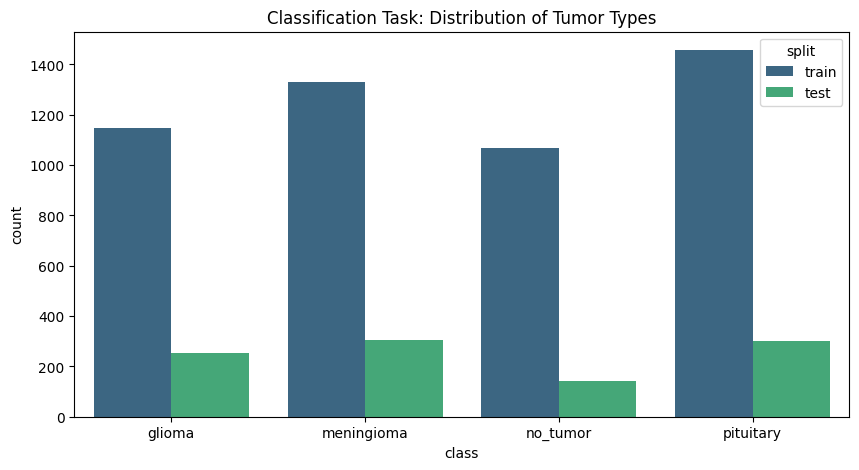

In [4]:
plt.figure(figsize=(10, 5))
sns.barplot(data=class_data, x='class', y='count', hue='split', palette='viridis')
plt.title('Classification Task: Distribution of Tumor Types')
plt.show()

In [5]:
for i in splits:
    image = sorted([os.path.basename(x) for x in glob.glob(os.path.join(BASE_DIR, 'segmentation_task', i, 'images', '*'))])
    mask  = sorted([os.path.basename(x) for x in glob.glob(os.path.join(BASE_DIR, 'segmentation_task', i, 'masks', '*'))])
    if len(image) == len(mask):
        print(f"All images and masks match for {i} set.")
    else:
        print(f"Mismatch found between images and masks in {i} set.")

All images and masks match for train set.
All images and masks match for test set.


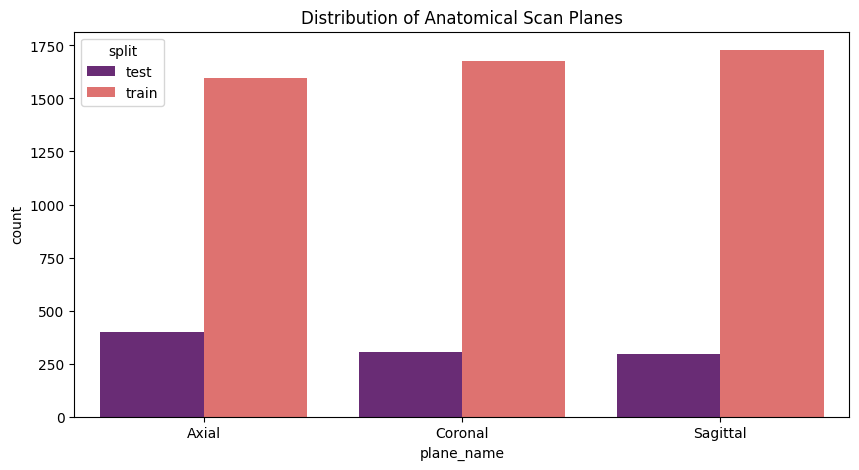

In [6]:
plane_data = []
all_class_images = glob.glob(os.path.join(BASE_DIR, 'classification_task', '*', '*', '*.jpg'))

for img_path in all_class_images:
    img_name = os.path.basename(img_path)
    parts = img_name.split('_')
    if len(parts) >= 5:
        plane_data.append({'split': parts[1], 'plane': parts[4]})

planedf = pd.DataFrame(plane_data)
plane_map = {'ax': 'Axial', 'co': 'Coronal', 'sa': 'Sagittal'}
planedf['plane_name'] = planedf['plane'].map(plane_map)

plt.figure(figsize=(10, 5))
sns.countplot(data=planedf, x='plane_name', hue='split', palette='magma')
plt.title('Distribution of Anatomical Scan Planes')
plt.show()

## Visual Inspection of the training data
We visualize the data to verify quality and observe tumor variability.

Sample with mask overlay:


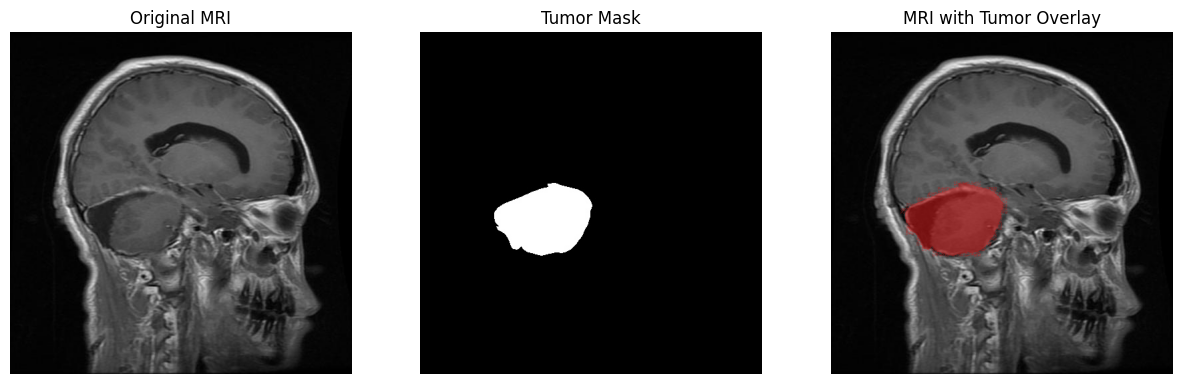


Classification samples grid:


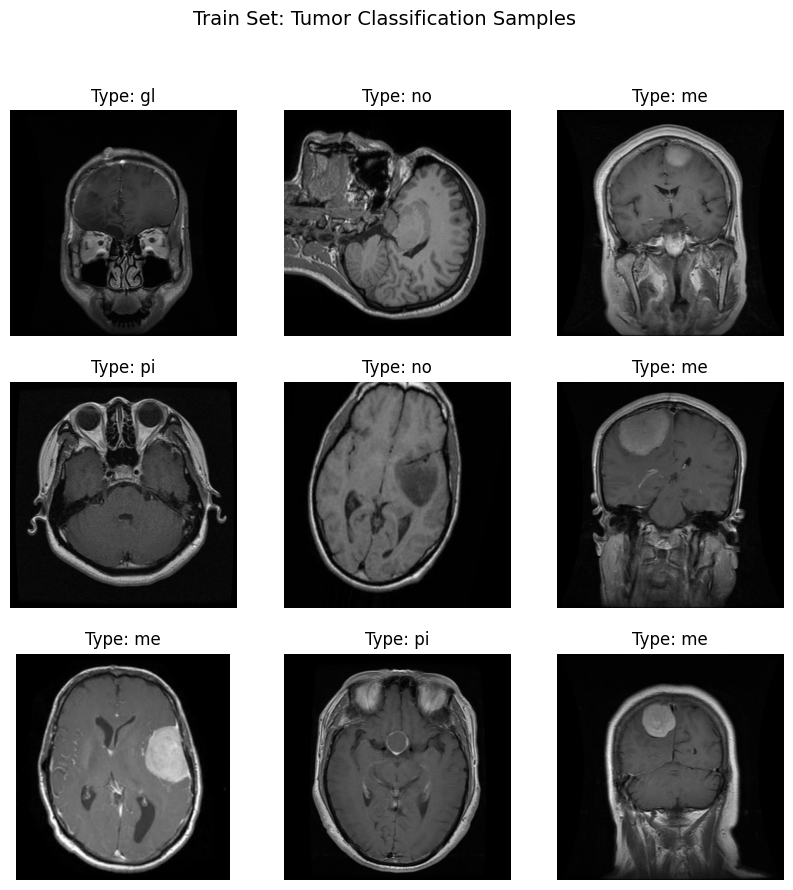

In [7]:
# Comprehensive Data Visualization Functions
def visualize_sample_with_mask(split='train', idx=976):
    """Display MRI image with its tumor mask"""
    img_file = sorted(glob.glob(os.path.join(BASE_DIR, 'segmentation_task', split, 'images', '*')))
    mask_file = sorted(glob.glob(os.path.join(BASE_DIR, 'segmentation_task', split, 'masks', '*')))
    
    image = Image.open(img_file[idx]).convert('RGB')
    mask = Image.open(mask_file[idx]).convert('L')
    
    img_array = np.array(image)
    mask_array = np.array(mask)
    masked_img = img_array.copy()
    masked_img[mask_array > 0] = [255, 0, 0]
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(image)
    axes[0].set_title("Original MRI")
    axes[0].axis('off')
    
    axes[1].imshow(mask, cmap='gray')
    axes[1].set_title("Tumor Mask")
    axes[1].axis('off')
    
    final = (img_array*0.6 + masked_img*0.4).astype(np.uint8)
    axes[2].imshow(final)
    axes[2].set_title("MRI with Tumor Overlay")
    axes[2].axis('off')
    plt.show()

def visualize_classification_grid(split='train', n_samples=9):
    """Display random grid of classification samples"""
    paths = glob.glob(os.path.join(BASE_DIR, 'classification_task', split, '*', '*.jpg'))
    selected_paths = np.random.choice(paths, min(n_samples, len(paths)), replace=False)
    
    plt.figure(figsize=(10, 10))
    for i, path in enumerate(selected_paths):
        plt.subplot(3, 3, i+1)
        img = Image.open(path)
        label = os.path.basename(path).split('_')[3]
        plt.imshow(img, cmap='gray')
        plt.title(f'Type: {label}')
        plt.axis('off')
    plt.suptitle(f'{split.capitalize()} Set: Tumor Classification Samples', fontsize=14)
    plt.show()

# Run visualizations
print("Sample with mask overlay:")
visualize_sample_with_mask('train', 976)

print("\nClassification samples grid:")
visualize_classification_grid('train', 9)

In [8]:
data_records = []
all_files = glob.glob(os.path.join(BASE_DIR, 'classification_task', '*', '*', '*.jpg'))

for f in all_files:
    parts = os.path.basename(f).split('_')
    # format: brisc2025_train_00001_gl_ax_t1.jpg
    if len(parts) == 6:
        row = {
            'path': f,
            'split': parts[1],
            'id': parts[2],
            'class_code': parts[3],
            'plane_code': parts[4],
            'sequence': parts[5].split('.')[0]
        }
        data_records.append(row)

meta_df = pd.DataFrame(data_records)
print("Metadata Summary Table:")
display(meta_df.head())
print(f"\nTotal parsed records: {len(meta_df)}")

Metadata Summary Table:


,path,split,id,class_code,plane_code,sequence
0,dataset/brisc2025\classification_task\test\gli...,test,00001,gl,ax,t1
1,dataset/brisc2025\classification_task\test\gli...,test,00002,gl,ax,t1
2,dataset/brisc2025\classification_task\test\gli...,test,00003,gl,ax,t1
3,dataset/brisc2025\classification_task\test\gli...,test,00004,gl,ax,t1
4,dataset/brisc2025\classification_task\test\gli...,test,00005,gl,ax,t1



Total parsed records: 6000


## Data Loading & Preprocessing Pipeline
Implementing PyTorch Dataset and DataLoader with proper transformations for U-Net training.

In [9]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision.transforms.functional as F
import random
from scipy.ndimage import gaussian_filter, map_coordinates

class squarepad:
    def __call__(self, image):
        w, h = image.size
        max_dim = max(w, h)
        wpad = (max_dim - h) // 2
        hpad = (max_dim - w) // 2
        padding = (hpad, wpad, max_dim - w - hpad, max_dim - h - wpad)
        return transforms.functional.pad(image, padding, fill=0, padding_mode='constant')
    
class denormalize:
    def __init__(self, mean, std):
        self.mean = mean
        self.std = std
        
    def __call__(self, tensor):
        tensor_copy = tensor.clone()
        for t, m, s in zip(tensor_copy, self.mean, self.std):
            t.mul_(s).add_(m)
        return tensor_copy

In [10]:
class elastic_transform:
    def __init__(self, alpha=34, sigma=4, random_state=None):
        self.alpha = alpha
        self.sigma = sigma
        self.random_state = random_state
        
    def __call__(self, image, mask=None):
        if isinstance(image, Image.Image):
            image = np.array(image)
            was_pil = True
        else:
            was_pil = False
        shape = image.shape
        
        # generating displacement fields
        if self.random_state is not None:
            random_state = np.random.RandomState(self.random_state)
        else:
            random_state = np.random.RandomState(None)
        
        dx = gaussian_filter((random_state.rand(*shape)*2-1), self.sigma)*self.alpha
        dy = gaussian_filter((random_state.rand(*shape)*2-1), self.sigma)*self.alpha
        
        # generating coordinates
        x, y = np.meshgrid(np.arange(shape[1]), np.arange(shape[0]))
        indices = np.reshape(y+dy, (-1,1)), np.reshape(x+dx, (-1,1))
        
        # transformation
        distorted_image = map_coordinates(image, indices, order=1, mode='reflect').reshape(shape)
        
        if mask is not None:
            if isinstance(mask, Image.Image):
                mask = np.array(mask)
                mask_was_pil = True
            else:
                mask_was_pil = False

            distorted_mask = map_coordinates(mask, indices, order=0, mode='reflect').reshape(shape)
            if mask_was_pil:
                distorted_mask = Image.fromarray(distorted_mask.astype(np.uint8))
            
            if was_pil:
                distorted_image = Image.fromarray(distorted_image.astype(np.uint8))
                
            return distorted_image, distorted_mask

        if was_pil:
            distorted_image = Image.fromarray(distorted_image.astype(np.uint8))
            
        return distorted_image

In [11]:
class brisc_segmentation(Dataset):
    def __init__(self, root_dir, split='train', img_size=256, augment=False, elasticity=0.5, val_split=0.2, is_validation=False, 
                mean=0.5, std=0.5):
        self.root_dir = root_dir
        self.split = split
        self.img_size = img_size
        self.augment = augment
        self.elasticity = elasticity
        self.mean = mean
        self.std = std
        
        # Determine the actual folder to read from
        folder_split = 'train' if (split == 'train' or is_validation) else split
        self.img_paths = os.path.join(root_dir, 'segmentation_task', folder_split, 'images')
        self.mask_paths = os.path.join(root_dir, 'segmentation_task', folder_split, 'masks')
        
        all_image_files = sorted(glob.glob(os.path.join(self.img_paths, '*.jpg')))
        all_mask_files = sorted(glob.glob(os.path.join(self.mask_paths, '*.png')))
        
        # Apply validation split if using train data
        if split == 'train' and not is_validation:
            # Keep first 80% for training
            split_idx = int(len(all_image_files) * (1 - val_split))
            self.image_files = all_image_files[:split_idx]
            self.mask_files = all_mask_files[:split_idx]
        elif is_validation:
            # Keep last 20% for validation
            split_idx = int(len(all_image_files) * (1 - val_split))
            self.image_files = all_image_files[split_idx:]
            self.mask_files = all_mask_files[split_idx:]
        else:
            # Test set - use all files
            self.image_files = all_image_files #use all test images
            self.mask_files = all_mask_files
        
        self.pad = squarepad()
        self.elastic = elastic_transform(alpha=34, sigma=4)
        
        set_name = 'validation' if is_validation else split
        print(f"Segmentation Dataset initialized: {len(self.image_files)} samples in {set_name} set.")
        
    def __len__(self):
        return len(self.image_files)
    
    def __getitem__(self,idx):
        # loading image and masks
        img = Image.open(self.image_files[idx]).convert('L')
        mask = Image.open(self.mask_files[idx]).convert('L')
        
        # synced transforms
        img, mask = self._transform(img,mask)
        
        # --> tensor and normalization
        img = transforms.functional.to_tensor(img)
        mask = transforms.functional.to_tensor(mask)
        
        img = transforms.functional.normalize(img, mean=[self.mean], std=[self.std])
        
        # binary mask
        mask = (mask > 0).float()
        
        return img, mask
    
    def _transform(self, img,mask):
        img = self.pad(img)
        mask = self.pad(mask)
        
        img = transforms.functional.resize(img, [self.img_size, self.img_size], interpolation=transforms.functional.InterpolationMode.BILINEAR)
        mask = transforms.functional.resize(mask, [self.img_size, self.img_size], interpolation=transforms.functional.InterpolationMode.NEAREST)
        
        if self.augment:
            if random.random()>0.5:
                img = transforms.functional.hflip(img)
                mask = transforms.functional.hflip(mask)
            
            if random.random()>0.5:
                angle = random.uniform(-10,10)
                img = transforms.functional.rotate(img,angle,interpolation=transforms.functional.InterpolationMode.BILINEAR)
                mask = transforms.functional.rotate(mask,angle,interpolation=transforms.functional.InterpolationMode.NEAREST)
            
            if random.random()<self.elasticity:
                img, mask = self.elastic(img, mask)
                
        return img, mask

In [12]:
class brisc_classificiation(Dataset):
    def __init__(self, root_dir, split='train', img_size=256, augment=False, val_split=0.2, is_validation=False, mean=0.5, std=0.5):
        self.root_dir = root_dir
        self.split = split
        self.img_size = img_size
        self.augment = augment and (split=='train') and not is_validation
        self.mean = mean
        self.std = std
        
        self.class_to_idx = {'glioma':0, 'meningioma':1, 'no_tumor':2, 'pituitary':3}
        self.idx_to_class = {v:k for k,v in self.class_to_idx.items()}
        
        # collecting all image paths and labels
        self.samples = []
        folder_split = 'train' if (split == 'train' or is_validation) else split
        base_path = os.path.join(root_dir, 'classification_task', folder_split)
        
        for i in self.class_to_idx.keys():
            class_path = os.path.join(base_path, i)
            if os.path.exists(class_path):
                files = sorted(glob.glob(os.path.join(class_path, '*.jpg')))
                for f in files:
                    self.samples.append((f, self.class_to_idx[i]))
        
        # Apply validation split if using train data
        if split == 'train' and not is_validation:
            # Keep first 80% for training
            split_idx = int(len(self.samples) * (1 - val_split))
            self.samples = self.samples[:split_idx]
        elif is_validation:
            # Keep last 20% for validation
            split_idx = int(len(self.samples) * (1 - val_split))
            self.samples = self.samples[split_idx:]
        
        set_name = 'validation' if is_validation else split
        print(f"Classification Dataset initialized: {len(self.samples)} samples for {set_name} set.")
        
        self.pad = squarepad()
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        
        img = Image.open(img_path).convert('L')
        img = self._transform(img)
        img = transforms.functional.to_tensor(img)
        img = transforms.functional.normalize(img, mean=[self.mean], std=[self.std])
        return img, label
    
    def _transform(self, img):
        img = self.pad(img)
        img = transforms.functional.resize(img, [self.img_size, self.img_size], interpolation=transforms.functional.InterpolationMode.BILINEAR)
        
        if self.augment:
            if random.random()>0.5:
                img = transforms.functional.hflip(img)
            if random.random()>0.5:
                angle = random.uniform(-30,30)
                img = transforms.functional.rotate(img,angle,interpolation=transforms.functional.InterpolationMode.BILINEAR)
            if random.random()>0.5:
                img = transforms.functional.adjust_brightness(img, random.uniform(0.8, 1.2))
                img = transforms.functional.adjust_contrast(img, random.uniform(0.8, 1.2))
        return img

In [13]:
# def calculate_dataset_statistics(dataset, num_samples=None):
#     print("Calculating dataset statistics...")
    
#     if num_samples is None:
#         num_samples = len(dataset)
#     else:
#         num_samples = min(num_samples, len(dataset))
    
#     pixel_values = []
    
#     for i in range(num_samples):
#         # Determine if segmentation or classification dataset
#         if hasattr(dataset, 'image_files'):
#             img_path = dataset.image_files[i]
#         else:
#             img_path = dataset.samples[i][0]
        
#         img = Image.open(img_path).convert('L')
#         img_array = np.array(img) / 255.0  # Normalize to [0, 1]
#         pixel_values.append(img_array.flatten())
        
#         if (i + 1) % 500 == 0:
#             print(f"  Processed {i + 1}/{num_samples} images...")
    
#     all_pixels = np.concatenate(pixel_values)
#     mean = np.mean(all_pixels)
#     std = np.std(all_pixels)
    
#     print(f"Statistics calculated from {num_samples} images:")
#     print(f"  Mean: {mean:.4f}")
#     print(f"  Std: {std:.4f}")
    
#     return mean, std

In [14]:
def calculate_class_weights(dataset):
    print("Calculating class weights for classification task...")
    
    # Count samples per class
    class_counts = {}
    for _, label in dataset.samples:
        class_counts[label] = class_counts.get(label, 0) + 1 #increment count
    
    n_total = len(dataset.samples)
    n_classes = len(class_counts) # number of unique classes
    
    # Calculate weights
    weights = torch.zeros(n_classes)
    for class_idx, count in class_counts.items():
        weights[class_idx] = n_total / (n_classes * count) 
    
    print(f"Class distribution:")
    for class_idx, count in sorted(class_counts.items()):
        class_name = dataset.idx_to_class[class_idx]
        print(f"  {class_name}: {count} samples (weight: {weights[class_idx]:.4f})")
    
    return weights

In [15]:
# Step 1: Calculate mean and std from training segmentation data
# Create a temporary dataset to calculate statistics (without augmentation)
# temp_dataset = brisc_segmentation(
#     root_dir=BASE_DIR,
#     split='train',
#     img_size=256,
#     augment=False
# )

# # Calculate statistics from training data
# TRAIN_MEAN, TRAIN_STD = calculate_dataset_statistics(temp_dataset)

# print(f"\nCalculated normalization parameters:")
# print(f"  Mean: {TRAIN_MEAN:.4f}")
# print(f"  Std: {TRAIN_STD:.4f}")
# print("\nThese values will be used for both segmentation and classification tasks.")

### Dataset Initialization
- **Training samples:** 3146

---

### Dataset Statistics Calculation
- Processed 500 / 3146 images  
- Processed 1000 / 3146 images  
- Processed 1500 / 3146 images  
- Processed 2000 / 3146 images  
- Processed 2500 / 3146 images  
- Processed 3000 / 3146 images  

---

### Final Dataset Statistics
- **Mean:** 0.1544  
- **Standard Deviation:** 0.1747  

---

### Normalization Parameters
The following values are used for **both segmentation and classification** tasks:
- **Mean:** 0.1544  
- **Std:** 0.1747  

---

### These values will be used for both segmentation and classification tasks. calculated only once because the values will stay the same over multiple runs, while the process consumes a lot of memory.

In [16]:
TRAIN_MEAN = 0.1544
TRAIN_STD = 0.1747

In [17]:
print("Creating Segmentation Datasets with validation split:")
train_seg_dataset = brisc_segmentation(
    root_dir=BASE_DIR,
    split='train', #default is train
    img_size=256, 
    augment=True,
    elasticity=0.5, #probability of applying elastic transform
    val_split=0.2,
    is_validation=False,
    mean=TRAIN_MEAN,
    std=TRAIN_STD
)

val_seg_dataset = brisc_segmentation(
    root_dir=BASE_DIR,
    split='train',
    img_size=256,
    augment=False,
    elasticity=0.0,
    val_split=0.2,
    is_validation=True,
    mean=TRAIN_MEAN,
    std=TRAIN_STD
)

test_seg_dataset = brisc_segmentation(
    root_dir=BASE_DIR,
    split='test',
    img_size=256,
    augment=False,
    mean=TRAIN_MEAN,
    std=TRAIN_STD
)

print("\nCreating Classification Datasets with validation split:")
train_cls_dataset = brisc_classificiation(
    root_dir=BASE_DIR,
    split='train',
    img_size=256,
    augment=True,
    val_split=0.2,
    is_validation=False,
    mean=TRAIN_MEAN,
    std=TRAIN_STD
)

val_cls_dataset = brisc_classificiation(
    root_dir=BASE_DIR,
    split='train',
    img_size=256,
    augment=False,
    val_split=0.2,
    is_validation=True,
    mean=TRAIN_MEAN,
    std=TRAIN_STD
)

test_cls_dataset = brisc_classificiation(
    root_dir=BASE_DIR,
    split='test',
    img_size=256,
    augment=False,
    mean=TRAIN_MEAN,
    std=TRAIN_STD
)

print("Dataset Summary:")
print(f"Segmentation - Train: {len(train_seg_dataset)}, Val: {len(val_seg_dataset)}, Test: {len(test_seg_dataset)}")
print(f"Classification - Train: {len(train_cls_dataset)}, Val: {len(val_cls_dataset)}, Test: {len(test_cls_dataset)}")

Creating Segmentation Datasets with validation split:
Segmentation Dataset initialized: 3146 samples in train set.
Segmentation Dataset initialized: 787 samples in validation set.
Segmentation Dataset initialized: 860 samples in test set.

Creating Classification Datasets with validation split:
Classification Dataset initialized: 4000 samples for train set.
Classification Dataset initialized: 1000 samples for validation set.
Classification Dataset initialized: 1000 samples for test set.
Dataset Summary:
Segmentation - Train: 3146, Val: 787, Test: 860
Classification - Train: 4000, Val: 1000, Test: 1000


In [18]:
class_weights = calculate_class_weights(train_cls_dataset) 
print("Class weights tensor (for nn.CrossEntropyLoss):") #use cross entropy loss to penalize heavily for confident error
print(f"Weights: {class_weights}")
print(f"\nUsage: criterion = nn.CrossEntropyLoss(weight=class_weights)") #

Calculating class weights for classification task...
Class distribution:
  glioma: 1147 samples (weight: 0.8718)
  meningioma: 1329 samples (weight: 0.7524)
  no_tumor: 1067 samples (weight: 0.9372)
  pituitary: 457 samples (weight: 2.1882)
Class weights tensor (for nn.CrossEntropyLoss):
Weights: tensor([0.8718, 0.7524, 0.9372, 2.1882])

Usage: criterion = nn.CrossEntropyLoss(weight=class_weights)


In [19]:
# Create DataLoaders with validation sets
BATCH_SIZE = 8
NUM_WORKERS = 0

# Segmentation DataLoaders
train_seg_loader = DataLoader(
    train_seg_dataset,
    batch_size=BATCH_SIZE, #how many samples per batch
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True #enable faster data transfer to GPU
)

val_seg_loader = DataLoader(
    val_seg_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False, 
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_seg_loader = DataLoader(
    test_seg_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

# Classification DataLoaders
train_cls_loader = DataLoader(
    train_cls_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_cls_loader = DataLoader(
    val_cls_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_cls_loader = DataLoader(
    test_cls_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print(f"DataLoaders created with batch_size={BATCH_SIZE}")
print(f"\nSegmentation:")
print(f"  Train: {len(train_seg_loader)} batches")
print(f"  Val: {len(val_seg_loader)} batches")
print(f"  Test: {len(test_seg_loader)} batches")
print(f"\nClassification:")
print(f"  Train: {len(train_cls_loader)} batches")
print(f"  Val: {len(val_cls_loader)} batches")
print(f"  Test: {len(test_cls_loader)} batches")

DataLoaders created with batch_size=8

Segmentation:
  Train: 394 batches
  Val: 99 batches
  Test: 108 batches

Classification:
  Train: 500 batches
  Val: 125 batches
  Test: 125 batches


In [20]:
# Verify the validation data is properly isolated and normalized 
print("Verification: Testing validation data isolation")
print(f"\nSegmentation - Train batch:")
img_train, mask_train = next(iter(train_seg_loader)) 
print(f"  Shape: {img_train.shape}, Range: [{img_train.min():.3f}, {img_train.max():.3f}]") #shape is batch_size x channels x height x width

print(f"\nSegmentation - Val batch:")
img_val, mask_val = next(iter(val_seg_loader))
print(f"  Shape: {img_val.shape}, Range: [{img_val.min():.3f}, {img_val.max():.3f}]") #range to check normalization

print(f"\nClassification - Train batch:")
img_train_cls, label_train = next(iter(train_cls_loader))
print(f"  Shape: {img_train_cls.shape}, Labels: {label_train.tolist()[:5]}...")

print(f"\nClassification - Val batch:")
img_val_cls, label_val = next(iter(val_cls_loader))
print(f"  Shape: {img_val_cls.shape}, Labels: {label_val.tolist()[:5]}...")

Verification: Testing validation data isolation

Segmentation - Train batch:
  Shape: torch.Size([8, 1, 256, 256]), Range: [-0.884, 4.571]

Segmentation - Val batch:
  Shape: torch.Size([8, 1, 256, 256]), Range: [-0.884, 4.683]

Classification - Train batch:
  Shape: torch.Size([8, 1, 256, 256]), Labels: [0, 2, 3, 0, 0]...

Classification - Val batch:
  Shape: torch.Size([8, 1, 256, 256]), Labels: [3, 3, 3, 3, 3]...


In [21]:
def visualize_preprocessing(dataset, idx=0, task='segmentation'):
    if task == 'segmentation':
        proc_img, proc_mask = dataset[idx]
        
        orig_img = Image.open(dataset.image_files[idx]).convert('L')
        orig_mask = Image.open(dataset.mask_files[idx]).convert('L')
        
        # Denormalize processed image for visualization using actual dataset stats
        denorm = denormalize(mean=[dataset.mean], std=[dataset.std])
        proc_img_vis = denorm(proc_img).squeeze().numpy() #squeeze to remove 1st channel dim (tensor shape: 1xHxW)
        proc_mask_vis = proc_mask.squeeze().numpy()
        
        # Plot
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        
        axes[0, 0].imshow(orig_img, cmap='gray')
        axes[0, 0].set_title(f'Original Image\n{orig_img.size[0]}x{orig_img.size[1]}') #width x height
        axes[0, 0].axis('off')
        
        axes[0, 1].imshow(orig_mask, cmap='gray')
        axes[0, 1].set_title('Original Mask')
        axes[0, 1].axis('off')

        axes[0, 2].hist(np.array(orig_img).flatten(), bins=50, color='blue', alpha=0.7)
        axes[0, 2].set_title('Original Intensity Distribution') 
        axes[0, 2].set_xlabel('Pixel Value')
        
        axes[1, 0].imshow(proc_img_vis, cmap='gray')
        axes[1, 0].set_title(f'Preprocessed Image\n{proc_img_vis.shape[0]}x{proc_img_vis.shape[1]}')
        axes[1, 0].axis('off')
        
        axes[1, 1].imshow(proc_mask_vis, cmap='gray')
        axes[1, 1].set_title('Preprocessed Mask')
        axes[1, 1].axis('off')
        
        axes[1, 2].hist(proc_img_vis.flatten(), bins=50, color='green', alpha=0.7)
        axes[1, 2].set_title('Preprocessed Intensity Distribution')
        axes[1, 2].set_xlabel('Normalized Value')
        
        plt.suptitle('Preprocessing Pipeline Visualization', fontsize=16)
        plt.tight_layout()
        plt.show()
    
    else:
        proc_img, label = dataset[idx]
        orig_img = Image.open(dataset.samples[idx][0]).convert('L')
        
        # Denormalize processed image for visualization using actual dataset stats
        denorm = denormalize(mean=[dataset.mean], std=[dataset.std])
        proc_img_vis = denorm(proc_img).squeeze().numpy()
        
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))
        axes[0].imshow(orig_img, cmap='gray')
        axes[0].set_title(f'Original Image\n{orig_img.size[0]}x{orig_img.size[1]}\nLabel: {dataset.idx_to_class[label]}')
        axes[0].axis('off')
        
        axes[1].imshow(proc_img_vis, cmap='gray')
        axes[1].set_title(f'Preprocessed Image\n{proc_img_vis.shape[0]}x{proc_img_vis.shape[1]}')
        axes[1].axis('off')
        
        plt.tight_layout()
        plt.show()

Segmentation Task Preprocessing:


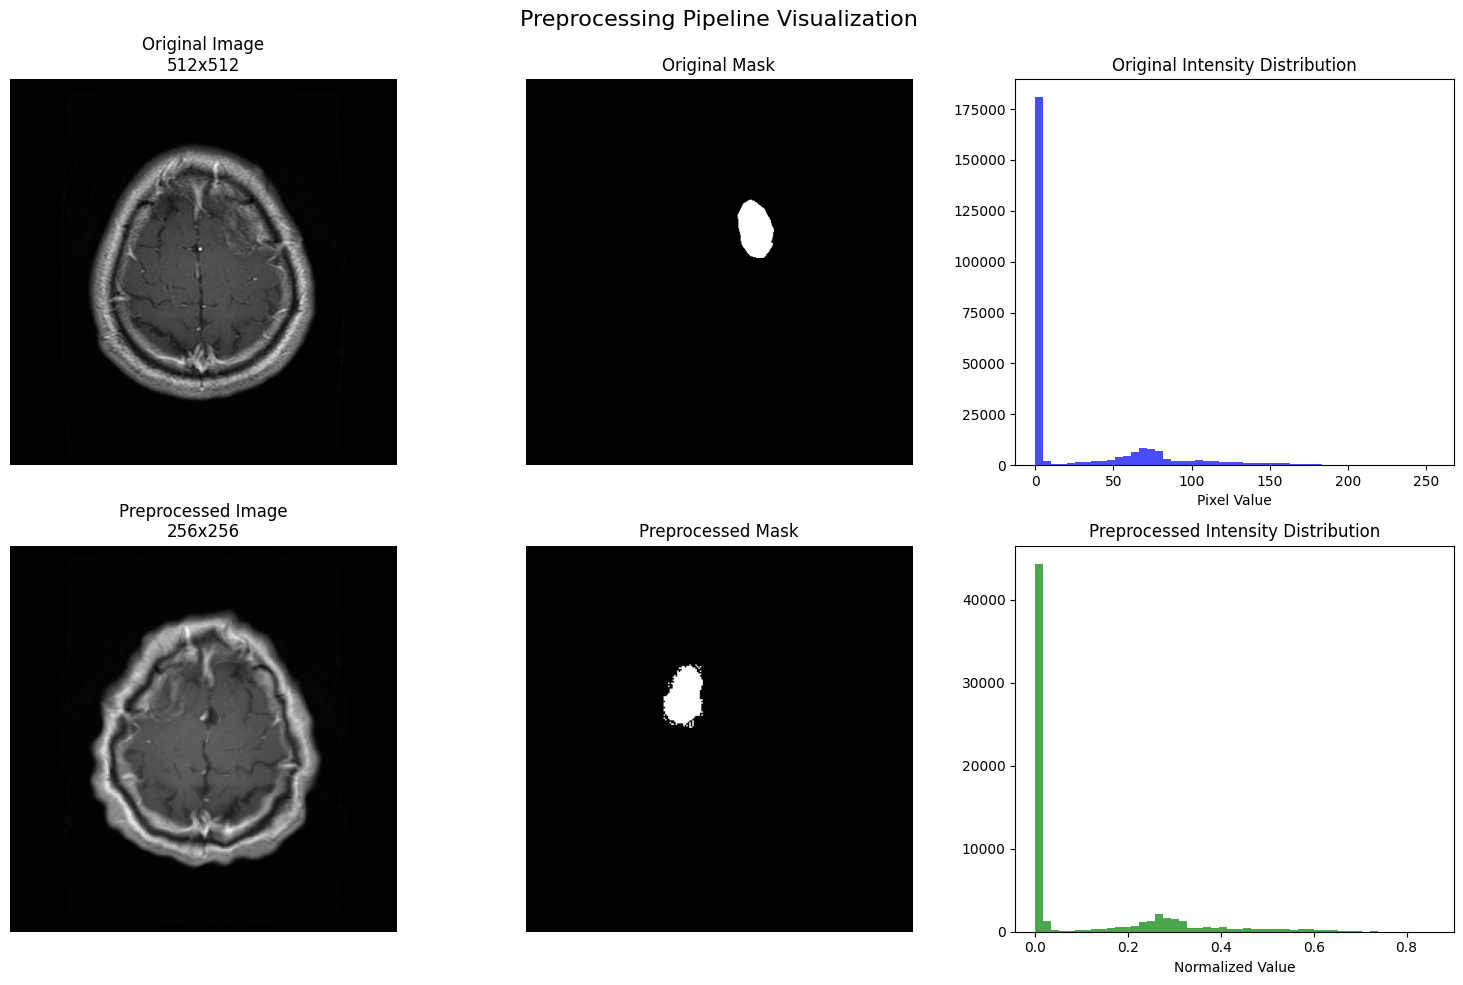

In [22]:
# Visualize segmentation preprocessing
print("Segmentation Task Preprocessing:")
visualize_preprocessing(train_seg_dataset, idx=100, task='segmentation')

Classification Task Preprocessing:


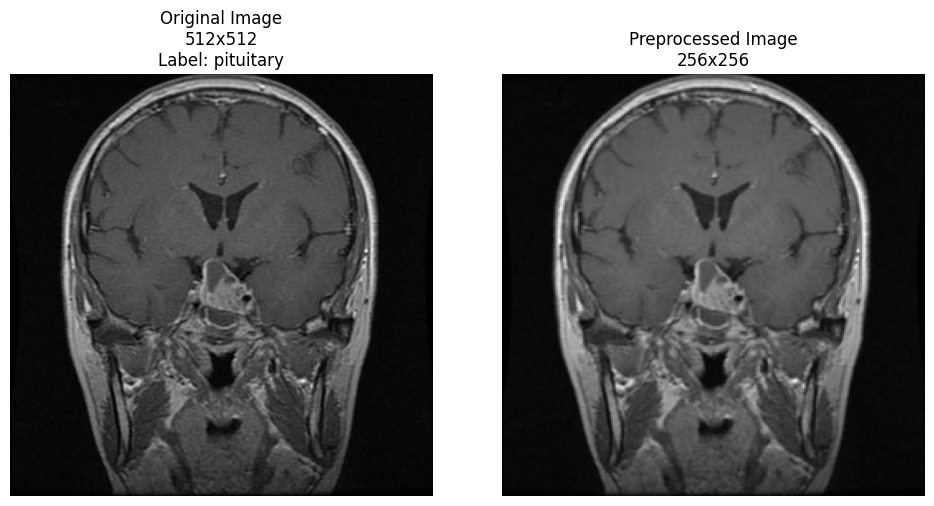

In [23]:
# Visualize classification preprocessing (use validation dataset to avoid augmentation artifacts)
print("Classification Task Preprocessing:")
visualize_preprocessing(val_cls_dataset, idx=100, task='classification')

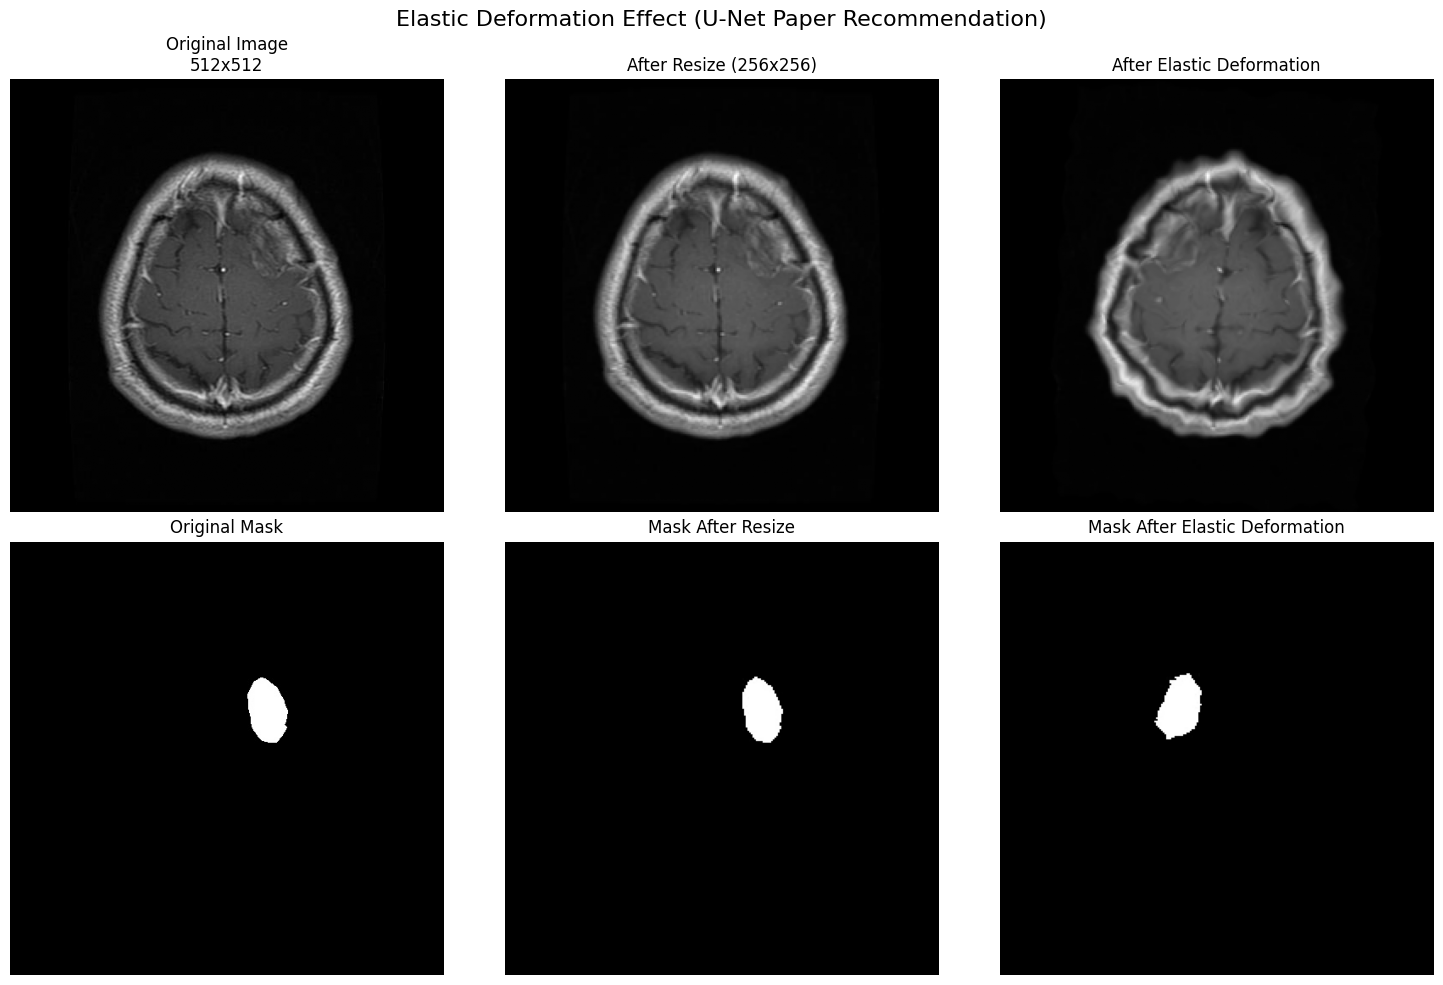

Note: Elastic deformation creates smooth, realistic tissue variations
without destroying anatomical structure - critical for small datasets.


In [24]:
def visualize_elastic_deformation(dataset, idx=100):
    original_prob = dataset.elasticity
    dataset.elasticity = 1.0
    
    orig_img = Image.open(dataset.image_files[idx]).convert('L')
    orig_mask = Image.open(dataset.mask_files[idx]).convert('L')
    
    img_padded = dataset.pad(orig_img)
    mask_padded = dataset.pad(orig_mask)
    img_resized = F.resize(img_padded, [256, 256], interpolation=F.InterpolationMode.BILINEAR)
    mask_resized = F.resize(mask_padded, [256, 256], interpolation=F.InterpolationMode.NEAREST)

    img_elastic, mask_elastic = dataset._transform(img_resized, mask_resized)

    dataset.elasticity = original_prob
    
    # Plot comparison
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    axes[0, 0].imshow(orig_img, cmap='gray')
    axes[0, 0].set_title(f'Original Image\n{orig_img.size[0]}x{orig_img.size[1]}')
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(img_resized, cmap='gray')
    axes[0, 1].set_title('After Resize (256x256)')
    axes[0, 1].axis('off')
    
    axes[0, 2].imshow(img_elastic, cmap='gray')
    axes[0, 2].set_title('After Elastic Deformation')
    axes[0, 2].axis('off')
    
    axes[1, 0].imshow(orig_mask, cmap='gray')
    axes[1, 0].set_title('Original Mask')
    axes[1, 0].axis('off')
    
    axes[1, 1].imshow(mask_resized, cmap='gray')
    axes[1, 1].set_title('Mask After Resize')
    axes[1, 1].axis('off')
    
    axes[1, 2].imshow(mask_elastic, cmap='gray')
    axes[1, 2].set_title('Mask After Elastic Deformation')
    axes[1, 2].axis('off')
    
    plt.suptitle('Elastic Deformation Effect (U-Net Paper Recommendation)', fontsize=16)
    plt.tight_layout()
    plt.show()
    
    print("Note: Elastic deformation creates smooth, realistic tissue variations")
    print("without destroying anatomical structure - critical for small datasets.")

visualize_elastic_deformation(train_seg_dataset, idx=100)

## Model Architecture: Standard U-Net (Modified) & Classifier Head

Implementation of:
1.  **Standard U-Net (Min Exp 1):** Following "Option A" (Padding=1, No cropping) as per project deviations.
2.  **Tumor Classifier (Min Exp 2):** Encoder-based classifier head for the 4-class prediction task.

In [25]:
import torch.nn as nn
import torch.nn.functional as F

class ConvBlock(nn.Module):
    """(convolution => [BN] => ReLU) * 2 - Modular building block"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential( #sequential container to stack layers
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1), #img --conv--> stack of featuers (size=out_chan) of that image 
            #ai can look at all these channels together to learn complex patterns about tumors
            
            nn.BatchNorm2d(out_channels), #forces all the numbers to follow a standard Bell Curve (Mean=0, Variance=1)
            nn.ReLU(inplace=True), #removes negative values keeping only positve where features are
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1), #stack --conv--> refined stack of combined features with same size
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True) 
        )

    def forward(self, x): 
        return self.double_conv(x) 

In [26]:
class UNetEncoder(nn.Module):
    """U-Net Encoder with skip connection outputs"""
    def __init__(self, in_channels=1, first_out_channel=64):
        super().__init__()
        
        self.enc1 = ConvBlock(in_channels, first_out_channel)
        self.enc2 = ConvBlock(first_out_channel, first_out_channel*2) #double the channels at each downsample
        self.enc3 = ConvBlock(first_out_channel*2, first_out_channel*4)
        self.enc4 = ConvBlock(first_out_channel*4, first_out_channel*8)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
    
    def forward(self, x): 
        x1 = self.enc1(x)              # 64 channels x 256 
        x2 = self.enc2(self.pool(x1))  # 128 channels x 128
        x3 = self.enc3(self.pool(x2))  # 256 channels x 64
        x4 = self.enc4(self.pool(x3))  # 512 channels x 32
        
        return x1, x2, x3, x4 #skip connections

In [27]:
class UNetBottleneck(nn.Module):
    """Bottleneck layer at the bottom of U-Net"""
    def __init__(self, in_channels=512):
        super().__init__()
        
        self.enc = ConvBlock(in_channels, in_channels*2)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
    
    def forward(self, x):
        return self.enc(self.pool(x))  # 1024 channels x 16

In [28]:
class DecoderBlock(nn.Module):
    """Decoder block with upsampling and skip connection concatenation"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        
        self.up = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2) #upsample by factor of 2
        self.conv = ConvBlock(2*out_channels, out_channels) #adjust input channels for skip connection 
    
    def forward(self, x, skip):
        x = self.up(x)
        x = torch.cat([skip, x], dim=1) #concatenate skip with upsampled feature map
        x = self.conv(x) #refine combined features
        return x

In [29]:
class AttentionBlock(nn.Module):

    def __init__(self, F_g, F_l, F_int):
        super(AttentionBlock, self).__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, stride=1, padding=0, bias=True), #compress the depth from Fg to F_int while keeping the spatial dimensions (height and width) identical 
            nn.BatchNorm2d(F_int)
        )
        
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1, stride=2, padding=0, bias=True), #stride=2 to match gating signal size
            nn.BatchNorm2d(F_int)
        )

        self.psi = nn.Sequential( 
            nn.Conv2d(F_int, 1, kernel_size=1, stride=1, padding=0, bias=True), #flatten to single channel 
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        
        self.relu = nn.ReLU(inplace=True)
        
    def forward(self, g, x):
        g1 = self.W_g(g) 
        x1 = self.W_x(x)
       # Psi is the raw 'overlap map' created by adding the Decoder's signal to the Encoder's signal to find where they agree
        psi = self.relu(g1 + x1) #adds gating signal and skip connection features then applies ReLU to only keep positive activations
        out = self.psi(psi) #squeeze to single channel and apply sigmoid to get between 0 and 1
        
        # Upsample the attention coefficients to match x's dimensions
        out = F.interpolate(out, size=x.size()[2:], mode='bilinear', align_corners=True)
        return x * out

In [30]:
class AttentionDecoderBlock(nn.Module):
    """Decoder block with Attention Gate"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        
        # Attention Gate
        # F_g = in_channels (from lower layer)
        # F_l = out_channels (skip connection has fewer channels typically)
        # F_int = out_channels // 2 (rule of thumb)
        self.attention = AttentionBlock(F_g=in_channels, F_l=out_channels, F_int=out_channels//2) #returns filtered skip connection
        
        self.up = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2) #upsample by factor of 2
        self.conv = ConvBlock(2*out_channels, out_channels) 
    
    def forward(self, x, skip):
        # x is the gating signal (g) for the attention mechanism
        # skip is the feature map (x) to be attended
        
        # Apply Attention Gate to skip connection
        attended_skip = self.attention(g=x, x=skip)
        
        # Standard U-Net Upsampling to match skip connection size
        x = self.up(x) 
        
        # Concatenate upsampled x with attended skip connection
        x = torch.cat([attended_skip, x], dim=1)
        x = self.conv(x) #conv to refine features
        return x

In [31]:
class AttentionUNetDecoder(nn.Module):
    """Decoder path using Attention Gates"""
    def __init__(self, in_channels=1024, n_classes=1):
        super().__init__()
        
        # Using AttentionDecoderBlock instead of standard DecoderBlock
        self.decode1 = AttentionDecoderBlock(in_channels, in_channels//2) #halve channels at each upsample
        self.decode2 = AttentionDecoderBlock(in_channels//2, in_channels//4) #in_channels is previous layer's out_channels
        self.decode3 = AttentionDecoderBlock(in_channels//4, in_channels//8)
        self.decode4 = AttentionDecoderBlock(in_channels//8, in_channels//16)
        
        self.final_conv = nn.Conv2d(in_channels//16, n_classes, kernel_size=1) #final "Judge." It looks at the 64 (in//16) features for each pixel and makes the final decision
    
    def forward(self, x5, x4, x3, x2, x1):
        # x5 is bottleneck output
        x = self.decode1(x5, x4) #upsample and attend with skip connection x4
        x = self.decode2(x, x3)
        x = self.decode3(x, x2)
        x = self.decode4(x, x1)
        return self.final_conv(x)

In [32]:
class AttentionUNet(nn.Module):
    """Attention U-Net combining standard encoder and bottleneck with attention decoder"""
    def __init__(self, n_channels=1, n_classes=1):
        super(AttentionUNet, self).__init__()
        self.n_channels = n_channels #1 for grayscale input
        self.n_classes = n_classes #1 for binary segmentation
        
        # Reuse existing modular components
        self.encoder = UNetEncoder(n_channels, 64) #first layer has 64 output channels, 1 input channel for grayscale
        self.bottleneck = UNetBottleneck(512) #input channels from last encoder layer
        
        # Use new Attention Decoder
        self.decoder = AttentionUNetDecoder(1024, n_classes) #bottleneck has 1024 channels, output is n_classes (1 for binary segmentation)

    def forward(self, x):
        # Encoder
        x1, x2, x3, x4 = self.encoder(x) #return skip connections
        
        # Bottleneck
        x5 = self.bottleneck(x4) #bottleneck output
        
        # Attention Decoder
        logits = self.decoder(x5, x4, x3, x2, x1) #pass skip connections along with bottleneck output 
        
        return logits #logits are raw scores before activation

In [33]:
# Test the AttentionUNet architecture
device = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'xpu' if hasattr(torch, 'xpu') and torch.xpu.is_available()
    else 'cpu'
)
attention_unet = AttentionUNet(n_channels=1, n_classes=1).to(device) #channels=1 for grayscale, classes=1 for binary segmentation

# Test with sample input
test_input = torch.randn(1, 1, 256, 256).to(device) #batch_size=1, channels=1, height=256, width=256
with torch.no_grad(): #disable gradient calculation for testing
    output = attention_unet(test_input)

print(f"AttentionUNet Architecture Test:")
print(f"Input shape: {test_input.shape}")
print(f"Output shape: {output.shape}")
print(f"Attention U-Net successfully instantiated on device: {device}")

# Count parameters
total_params = sum(p.numel() for p in attention_unet.parameters()) #numel() gives total number of elements in the tensor
print(f"Total parameters: {total_params:,}")

AttentionUNet Architecture Test:
Input shape: torch.Size([1, 1, 256, 256])
Output shape: torch.Size([1, 1, 256, 256])
Attention U-Net successfully instantiated on device: xpu
Total parameters: 31,567,981


In [34]:
class UNetDecoder(nn.Module):
    """U-Net Decoder with skip connections"""
    def __init__(self, in_channels=1024, n_classes=1):
        super().__init__()
        
        self.decode1 = DecoderBlock(in_channels, in_channels//2) #halve channels at each upsample
        self.decode2 = DecoderBlock(in_channels//2, in_channels//4)
        self.decode3 = DecoderBlock(in_channels//4, in_channels//8)
        self.decode4 = DecoderBlock(in_channels//8, in_channels//16)
        
        self.final_conv = nn.Conv2d(in_channels//16, n_classes, kernel_size=1) #looks at 64 (in//16) features for each pixel, makes the final decision, n_classes=1 
    
    def forward(self, x5, x4, x3, x2, x1):
        x = self.decode1(x5, x4) #upsample and concatenate with skip connection x4
        x = self.decode2(x, x3)
        x = self.decode3(x, x2)
        x = self.decode4(x, x1)
        return self.final_conv(x)

In [35]:
class Classifier(nn.Module):
    """Classification head that takes bottleneck features as input"""
    def __init__(self, in_channels=1024, num_classes=4):
        super().__init__()
        
        self.dropout = nn.Dropout(p=0.5) #dropout to prevent overfitting
        self.conv1 = nn.Conv2d(in_channels, in_channels//2, 3, padding=1) #3 means 3x3 kernel
        self.bn1 = nn.BatchNorm2d(in_channels//2)
        self.conv2 = nn.Conv2d(in_channels//2, in_channels//4, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(in_channels//4)
        self.conv3 = nn.Conv2d(in_channels//4, num_classes, 3, padding=1) # num_classes =4 for 4 classes of tumor

    def forward(self, x):
        # Takes bottleneck features (1024 x 16 x 16)
        x = F.max_pool2d(F.relu(self.bn1(self.conv1(x))), 2, stride=2)  # 512 x 8 x 8
        x = F.max_pool2d(F.relu(self.bn2(self.conv2(x))), 2, stride=2)  # 256 x 4 x 4
        x = self.dropout(x)
        x = F.adaptive_avg_pool2d(self.conv3(x), (1, 1)).squeeze((-1, -2))  #avg pool to 1x1 then squeeze to get (batch_size x num_classes) remove last two dims
        return x #return raw scores (logits) for each tumor type

## Loss Functions & Metrics

Implementing Dice Loss, IoU, and evaluation metrics for segmentation and classification.

In [36]:
class DiceLoss(nn.Module):
    """Dice Loss for segmentation tasks"""
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth
    
    def forward(self, pred, target):
        pred = torch.sigmoid(pred)
        pred_flat = pred.view(-1)
        target_flat = target.view(-1)
        
        intersection = (pred_flat * target_flat).sum()
        dice = (2. * intersection + self.smooth) / (pred_flat.sum() + target_flat.sum() + self.smooth)
        
        return 1 - dice

def calculate_iou(pred, target, threshold=0.5):
    """Calculate Intersection over Union (IoU) for segmentation"""
    pred = torch.sigmoid(pred)
    pred = (pred > threshold).float()
    target = target.float()
    
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    
    iou = (intersection + 1e-6) / (union + 1e-6)
    return iou.item()

def calculate_dice_score(pred, target, threshold=0.5):
    """Calculate Dice Score for segmentation"""
    pred = torch.sigmoid(pred)
    pred = (pred > threshold).float()
    target = target.float()
    
    pred_flat = pred.view(-1)
    target_flat = target.view(-1)
    
    intersection = (pred_flat * target_flat).sum()
    dice = (2. * intersection + 1e-6) / (pred_flat.sum() + target_flat.sum() + 1e-6)
    
    return dice.item()

## Training Strategy 1 and 2: Separate Training vs Joint Training

Training segmentation and classification separately (baseline approach).

In [37]:
def train_model(encoder, bottleneck, decoder_or_attention_decoder, classifier=None,
                seg_train_loader=None, seg_val_loader=None,
                cls_train_loader=None, cls_val_loader=None,
                mode='segmentation', epochs=20, lr=0.001, device='cpu',
                w_seg=1.0, w_cls=0.1, class_weights=None, save_path=None, freeze_encoder=False):
    """
    Unified training function for all three training strategies.
    
    Args:
        encoder: Encoder module (shared across all modes)
        bottleneck: Bottleneck module
        decoder_or_attention_decoder: Decoder for segmentation (regular or attention)
        classifier: Classifier module (required for classification/joint modes)
        seg_train_loader, seg_val_loader: Segmentation data loaders
        cls_train_loader, cls_val_loader: Classification data loaders
        mode: 'segmentation', 'classification', or 'joint'
        epochs: Number of training epochs
        lr: Learning rate
        device: Training device
        w_seg: Weight for segmentation loss (joint mode)
        w_cls: Weight for classification loss (joint mode)
        class_weights: Class weights for classification loss
        save_path: Custom save path (optional). If None, uses default paths.
        freeze_encoder: If True, freezes encoder weights (only for classification mode)
    
    Returns:
        history: Dictionary containing training metrics
    """
    
    print(f"UNIFIED TRAINING - MODE: {mode}")
    
    if mode == 'segmentation':
        if seg_train_loader is None or seg_val_loader is None:
            raise ValueError("Segmentation loaders required for segmentation mode")
        print("Training: Encoder + Bottleneck + Decoder (Segmentation Only)")
        
    elif mode == 'classification':
        if cls_train_loader is None or cls_val_loader is None or classifier is None:
            raise ValueError("Classification loaders and classifier required for classification mode")
        print("Training: Encoder + Bottleneck + Classifier (Classification Only)")
        if freeze_encoder:
            print("  Encoder: FROZEN (pre-trained weights from segmentation)")
            # Freeze encoder parameters
            for param in encoder.parameters():
                param.requires_grad = False
        else:
            print("  Encoder: TRAINABLE")
            
    elif mode == 'joint':
        if (seg_train_loader is None or seg_val_loader is None or 
            cls_train_loader is None or cls_val_loader is None or classifier is None):
            raise ValueError("Both segmentation and classification loaders plus classifier required for joint mode")
        print("Training: Encoder + Bottleneck + Decoder + Classifier (Multi-task)")
        print(f"  Loss weights: Segmentation={w_seg}, Classification={w_cls}")
    else:
        raise ValueError(f"Invalid mode: {mode}. Choose 'segmentation', 'classification', or 'joint'")
    
    # Setup optimizer based on mode
    if mode == 'segmentation':
        all_params = (list(encoder.parameters()) + list(bottleneck.parameters()) + 
                     list(decoder_or_attention_decoder.parameters()))
    elif mode == 'classification':
        if freeze_encoder:
            # Only train bottleneck and classifier when encoder is frozen
            all_params = list(bottleneck.parameters()) + list(classifier.parameters())
        else:
            all_params = (list(encoder.parameters()) + list(bottleneck.parameters()) + 
                         list(classifier.parameters()))
    else:  # joint
        all_params = (list(encoder.parameters()) + list(bottleneck.parameters()) + 
                     list(decoder_or_attention_decoder.parameters()) + list(classifier.parameters()))
    
    optimizer = torch.optim.AdamW(all_params, lr=lr, weight_decay=1e-2)
    
    # Loss functions
    dice_loss_fn = DiceLoss()
    bce_loss_fn = nn.BCEWithLogitsLoss()
    
    if class_weights is not None:
        cls_loss_fn = nn.CrossEntropyLoss(weight=class_weights.to(device), label_smoothing=0.137)
    else:
        cls_loss_fn = nn.CrossEntropyLoss()
    
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3) 
    
    # Initialize history based on mode
    if mode == 'segmentation':
        history = {'train_loss': [], 'train_dice': [], 'train_iou': [],
                  'val_loss': [], 'val_dice': [], 'val_iou': []}
    elif mode == 'classification':
        history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    else:  # joint
        history = {
            'train_seg_loss': [], 'train_dice': [], 'train_iou': [],
            'train_cls_loss': [], 'train_acc': [],
            'val_seg_loss': [], 'val_dice': [], 'val_iou': [],
            'val_cls_loss': [], 'val_acc': []
        }
    
    # Training loop
    for epoch in range(epochs):
        # Set models to train mode
        encoder.train()
        bottleneck.train()
        if decoder_or_attention_decoder is not None:
            decoder_or_attention_decoder.train()
        if classifier is not None:
            classifier.train()
        
        # Training phase
        if mode == 'segmentation':
            train_loss, train_dice, train_iou = 0.0, 0.0, 0.0
            
            for images, masks in seg_train_loader:
                images, masks = images.to(device), masks.to(device)
                
                x1, x2, x3, x4 = encoder(images)
                x5 = bottleneck(x4)
                outputs = decoder_or_attention_decoder(x5, x4, x3, x2, x1)
                
                bce = bce_loss_fn(outputs, masks)
                dice = dice_loss_fn(outputs, masks)
                loss = 0.2 * bce + 0.8 * dice #combined loss
                
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                
                train_loss += loss.item()
                train_dice += calculate_dice_score(outputs, masks)
                train_iou += calculate_iou(outputs, masks)
            train_loss /= len(seg_train_loader)
            train_dice /= len(seg_train_loader)
            train_iou /= len(seg_train_loader)
            
        elif mode == 'classification':
            train_loss = 0.0
            train_correct = 0
            train_total = 0
            
            for images, labels in cls_train_loader:
                images, labels = images.to(device), labels.to(device)
                
                x1, x2, x3, x4 = encoder(images)
                x5 = bottleneck(x4)
                outputs = classifier(x5)
                loss = cls_loss_fn(outputs, labels)
                
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                
                train_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                train_total += labels.size(0)
                train_correct += (predicted == labels).sum().item()
            
            train_loss /= len(cls_train_loader)
            train_acc = train_correct / train_total
            
        else:  # joint
            train_seg_loss, train_cls_loss = 0.0, 0.0
            train_dice, train_iou = 0.0, 0.0
            train_correct, train_total = 0, 0
            
            seg_iter = iter(seg_train_loader)
            cls_iter = iter(cls_train_loader)
            num_batches = min(len(seg_train_loader), len(cls_train_loader))
            
            for _ in range(num_batches):
                # Segmentation batch
                try:
                    seg_images, seg_masks = next(seg_iter)
                except StopIteration:
                    seg_iter = iter(seg_train_loader)
                    seg_images, seg_masks = next(seg_iter)
                
                seg_images, seg_masks = seg_images.to(device), seg_masks.to(device)
                x1, x2, x3, x4 = encoder(seg_images)
                x5 = bottleneck(x4)
                seg_outputs = decoder_or_attention_decoder(x5, x4, x3, x2, x1)
                
                bce = bce_loss_fn(seg_outputs, seg_masks)
                dice = dice_loss_fn(seg_outputs, seg_masks)
                seg_loss = 0.2 * bce + 0.8 * dice
                
                # Classification batch
                try:
                    cls_images, cls_labels = next(cls_iter)
                except StopIteration:
                    cls_iter = iter(cls_train_loader)
                    cls_images, cls_labels = next(cls_iter)
                
                cls_images, cls_labels = cls_images.to(device), cls_labels.to(device)
                x1_cls, x2_cls, x3_cls, x4_cls = encoder(cls_images)
                x5_cls = bottleneck(x4_cls)
                cls_outputs = classifier(x5_cls)
                cls_loss = cls_loss_fn(cls_outputs, cls_labels)
                
                # Combined loss
                total_loss = w_seg * seg_loss + w_cls * cls_loss
                
                optimizer.zero_grad()
                total_loss.backward()
                optimizer.step()
                
                train_seg_loss += seg_loss.item()
                train_cls_loss += cls_loss.item()
                train_dice += calculate_dice_score(seg_outputs, seg_masks)
                train_iou += calculate_iou(seg_outputs, seg_masks)
                _, predicted = torch.max(cls_outputs.data, 1)
                train_total += cls_labels.size(0)
                train_correct += (predicted == cls_labels).sum().item()
            
            train_seg_loss /= num_batches
            train_cls_loss /= num_batches
            train_dice /= num_batches
            train_iou /= num_batches
            train_acc = train_correct / train_total
        
        # Validation phase
        encoder.eval()
        bottleneck.eval()
        if decoder_or_attention_decoder is not None:
            decoder_or_attention_decoder.eval()
        if classifier is not None:
            classifier.eval()
        
        with torch.no_grad():
            if mode == 'segmentation':
                val_loss, val_dice, val_iou = 0.0, 0.0, 0.0
                
                for images, masks in seg_val_loader:
                    images, masks = images.to(device), masks.to(device)
                    x1, x2, x3, x4 = encoder(images)
                    x5 = bottleneck(x4)
                    outputs = decoder_or_attention_decoder(x5, x4, x3, x2, x1)
                    
                    bce = bce_loss_fn(outputs, masks)
                    dice = dice_loss_fn(outputs, masks)
                    loss = 0.2 * bce + 0.8 * dice
                    
                    val_loss += loss.item()
                    val_dice += calculate_dice_score(outputs, masks)
                    val_iou += calculate_iou(outputs, masks)
                val_loss /= len(seg_val_loader)
                val_dice /= len(seg_val_loader)
                val_iou /= len(seg_val_loader)
                
            elif mode == 'classification':
                val_loss = 0.0
                val_correct = 0
                val_total = 0
                
                for images, labels in cls_val_loader:
                    images, labels = images.to(device), labels.to(device)
                    x1, x2, x3, x4 = encoder(images)
                    x5 = bottleneck(x4)
                    outputs = classifier(x5)
                    loss = cls_loss_fn(outputs, labels)
                    
                    val_loss += loss.item()
                    _, predicted = torch.max(outputs.data, 1)
                    val_total += labels.size(0)
                    val_correct += (predicted == labels).sum().item()
                
                val_loss /= len(cls_val_loader)
                val_acc = val_correct / val_total
                
            else:  # joint
                val_seg_loss, val_cls_loss = 0.0, 0.0
                val_dice, val_iou = 0.0, 0.0
                val_correct, val_total = 0, 0
                
                for images, masks in seg_val_loader:
                    images, masks = images.to(device), masks.to(device)
                    x1, x2, x3, x4 = encoder(images)
                    x5 = bottleneck(x4)
                    outputs = decoder_or_attention_decoder(x5, x4, x3, x2, x1)
                    
                    bce = bce_loss_fn(outputs, masks)
                    dice = dice_loss_fn(outputs, masks)
                    loss = 0.2 * bce + 0.8 * dice
                    
                    val_seg_loss += loss.item()
                    val_dice += calculate_dice_score(outputs, masks)
                    val_iou += calculate_iou(outputs, masks)
                val_seg_loss /= len(seg_val_loader)
                val_dice /= len(seg_val_loader)
                val_iou /= len(seg_val_loader)
                
                for images, labels in cls_val_loader:
                    images, labels = images.to(device), labels.to(device)
                    x1, x2, x3, x4 = encoder(images)
                    x5 = bottleneck(x4)
                    outputs = classifier(x5)
                    loss = cls_loss_fn(outputs, labels)
                    
                    val_cls_loss += loss.item()
                    _, predicted = torch.max(outputs.data, 1)
                    val_total += labels.size(0)
                    val_correct += (predicted == labels).sum().item()
                
                val_cls_loss /= len(cls_val_loader)
                val_acc = val_correct / val_total
        
        # Update scheduler
        if mode == 'segmentation':
            scheduler.step(val_loss)
        elif mode == 'classification':
            scheduler.step(val_loss)
        else:  # joint
            total_val_loss = w_seg * val_seg_loss + w_cls * val_cls_loss
            scheduler.step(total_val_loss)
        
        # Store history
        if mode == 'segmentation':
            history['train_loss'].append(train_loss)
            history['train_dice'].append(train_dice)
            history['train_iou'].append(train_iou)
            history['val_loss'].append(val_loss)
            history['val_dice'].append(val_dice)
            history['val_iou'].append(val_iou)
        elif mode == 'classification':
            history['train_loss'].append(train_loss)
            history['train_acc'].append(train_acc)
            history['val_loss'].append(val_loss)
            history['val_acc'].append(val_acc)
        else:  # joint
            history['train_seg_loss'].append(train_seg_loss)
            history['train_cls_loss'].append(train_cls_loss)
            history['train_dice'].append(train_dice)
            history['train_iou'].append(train_iou)
            history['train_acc'].append(train_acc)
            history['val_seg_loss'].append(val_seg_loss)
            history['val_cls_loss'].append(val_cls_loss)
            history['val_dice'].append(val_dice)
            history['val_iou'].append(val_iou)
            history['val_acc'].append(val_acc)
        
        # Print progress
        if (epoch + 1) % 2 == 0 or epoch == 0:
            print(f"\nEpoch [{epoch+1}/{epochs}]")
            if mode == 'segmentation':
                print(f"  Train - Loss: {train_loss:.4f}, Dice: {train_dice:.4f}, IoU: {train_iou:.4f}")
                print(f"  Val   - Loss: {val_loss:.4f}, Dice: {val_dice:.4f}, IoU: {val_iou:.4f}")
            elif mode == 'classification':
                print(f"  Train - Loss: {train_loss:.4f}, Acc: {train_acc:.4f}")
                print(f"  Val   - Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")
            else:  # joint
                print(f"  Train - Seg Loss: {train_seg_loss:.4f}, Dice: {train_dice:.4f}, IoU: {train_iou:.4f}")
                print(f"         Cls Loss: {train_cls_loss:.4f}, Acc: {train_acc:.4f}")
                print(f"  Val   - Seg Loss: {val_seg_loss:.4f}, Dice: {val_dice:.4f}, IoU: {val_iou:.4f}")
                print(f"         Cls Loss: {val_cls_loss:.4f}, Acc: {val_acc:.4f}")
    
    # Save final model
    if mode == 'segmentation':
        torch.save({
            'encoder': encoder.state_dict(),
            'bottleneck': bottleneck.state_dict(),
            'decoder': decoder_or_attention_decoder.state_dict(),
            'optimizer': optimizer.state_dict(),
            'scheduler': scheduler.state_dict(),
            'history': history
        }, 'best_segmentation_separate.pth')
        print(f"\nSegmentation training complete! Final Val Dice: {val_dice:.4f}")
        print("Model saved to: best_segmentation_separate.pth")
        
    elif mode == 'classification':
        torch.save({
            'encoder': encoder.state_dict(),
            'bottleneck': bottleneck.state_dict(),
            'classifier': classifier.state_dict(),
            'optimizer': optimizer.state_dict(),
            'scheduler': scheduler.state_dict(),
            'history': history
        }, 'best_classification_separate.pth')
        print(f"\nClassification training complete! Final Val Acc: {val_acc:.4f}")
        print("Model saved to: best_classification_separate.pth")
        
    else:  # joint
        combined_score = val_dice * 0.5 + val_acc * 0.5
        
        # Use custom save path or default
        if save_path is None:
            save_path = 'best_joint_training.pth'
        
        torch.save({
            'encoder': encoder.state_dict(),
            'bottleneck': bottleneck.state_dict(),
            'decoder': decoder_or_attention_decoder.state_dict(),
            'classifier': classifier.state_dict(),
            'optimizer': optimizer.state_dict(),
            'scheduler': scheduler.state_dict(),
            'history': history
        }, save_path)
        print(f"\nJoint training complete! Dice: {val_dice:.4f}, Acc: {val_acc:.4f}, Combined: {combined_score:.4f}")
        print(f"Model saved to: {save_path}")
    
    return history

## Comparison & Visualization Utilities

Functions to compare separate vs joint training performance.

In [38]:
def plot_training_comparison_from_checkpoints(seg_checkpoint_path, cls_checkpoint_path, joint_checkpoint_path):
    """
    Compare separate vs joint training by loading histories from checkpoint files.
    This ensures consistency across multiple training runs.
    
    Args:
        seg_checkpoint_path: Path to separate segmentation checkpoint (.pth)
        cls_checkpoint_path: Path to separate classification checkpoint (.pth)
        joint_checkpoint_path: Path to joint training checkpoint (.pth)
    """
    # Load checkpoints
    if not os.path.exists(seg_checkpoint_path):
        print(f"ERROR: Segmentation checkpoint not found: {seg_checkpoint_path}")
        return
    if not os.path.exists(cls_checkpoint_path):
        print(f"ERROR: Classification checkpoint not found: {cls_checkpoint_path}")
        return
    if not os.path.exists(joint_checkpoint_path):
        print(f"ERROR: Joint checkpoint not found: {joint_checkpoint_path}")
        return
    
    print(f"\nLoading checkpoints for comparison...")
    seg_checkpoint = torch.load(seg_checkpoint_path, map_location='cpu')
    cls_checkpoint = torch.load(cls_checkpoint_path, map_location='cpu')
    joint_checkpoint = torch.load(joint_checkpoint_path, map_location='cpu')
    
    # Extract histories
    sep_seg_history = seg_checkpoint.get('history', None)
    sep_cls_history = cls_checkpoint.get('history', None)
    joint_history = joint_checkpoint.get('history', None)
    
    if sep_seg_history is None:
        print(f"ERROR: No history found in segmentation checkpoint")
        return
    if sep_cls_history is None:
        print(f"ERROR: No history found in classification checkpoint")
        return
    if joint_history is None:
        print(f"ERROR: No history found in joint checkpoint")
        return
    
    print(f"Loaded segmentation history (Epoch {seg_checkpoint.get('epoch', 'N/A')})")
    print(f"Loaded classification history (Epoch {cls_checkpoint.get('epoch', 'N/A')})")
    print(f"Loaded joint training history (Epoch {joint_checkpoint.get('epoch', 'N/A')})")
    
    # Create comparison plots
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('Training Comparison: Separate vs Joint (From Saved Checkpoints)', fontsize=16, fontweight='bold')
    
    epochs_sep_seg = range(1, len(sep_seg_history['train_loss']) + 1)
    epochs_sep_cls = range(1, len(sep_cls_history['train_loss']) + 1)
    epochs_joint = range(1, len(joint_history['train_seg_loss']) + 1)
    
    # 1. Segmentation Loss
    axes[0, 0].plot(epochs_sep_seg, sep_seg_history['train_loss'], 'b-', label='Separate Train', linewidth=2)
    axes[0, 0].plot(epochs_sep_seg, sep_seg_history['val_loss'], 'b--', label='Separate Val', linewidth=2)
    axes[0, 0].plot(epochs_joint, joint_history['train_seg_loss'], 'r-', label='Joint Train', linewidth=2)
    axes[0, 0].plot(epochs_joint, joint_history['val_seg_loss'], 'r--', label='Joint Val', linewidth=2)
    axes[0, 0].set_title('Segmentation Loss', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Dice Score
    axes[0, 1].plot(epochs_sep_seg, sep_seg_history['train_dice'], 'b-', label='Separate Train', linewidth=2)
    axes[0, 1].plot(epochs_sep_seg, sep_seg_history['val_dice'], 'b--', label='Separate Val', linewidth=2)
    axes[0, 1].plot(epochs_joint, joint_history['train_dice'], 'r-', label='Joint Train', linewidth=2)
    axes[0, 1].plot(epochs_joint, joint_history['val_dice'], 'r--', label='Joint Val', linewidth=2)
    axes[0, 1].set_title('Dice Score (Segmentation)', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Dice Score')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. IoU Score
    axes[0, 2].plot(epochs_sep_seg, sep_seg_history['train_iou'], 'b-', label='Separate Train', linewidth=2)
    axes[0, 2].plot(epochs_sep_seg, sep_seg_history['val_iou'], 'b--', label='Separate Val', linewidth=2)
    axes[0, 2].plot(epochs_joint, joint_history['train_iou'], 'r-', label='Joint Train', linewidth=2)
    axes[0, 2].plot(epochs_joint, joint_history['val_iou'], 'r--', label='Joint Val', linewidth=2)
    axes[0, 2].set_title('IoU Score (Segmentation)', fontsize=12, fontweight='bold')
    axes[0, 2].set_xlabel('Epoch')
    axes[0, 2].set_ylabel('IoU')
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3)
    
    # 4. Classification Loss
    axes[1, 0].plot(epochs_sep_cls, sep_cls_history['train_loss'], 'b-', label='Separate Train', linewidth=2)
    axes[1, 0].plot(epochs_sep_cls, sep_cls_history['val_loss'], 'b--', label='Separate Val', linewidth=2)
    axes[1, 0].plot(epochs_joint, joint_history['train_cls_loss'], 'r-', label='Joint Train', linewidth=2)
    axes[1, 0].plot(epochs_joint, joint_history['val_cls_loss'], 'r--', label='Joint Val', linewidth=2)
    axes[1, 0].set_title('Classification Loss', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Loss')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # 5. Classification Accuracy
    axes[1, 1].plot(epochs_sep_cls, sep_cls_history['train_acc'], 'b-', label='Separate Train', linewidth=2)
    axes[1, 1].plot(epochs_sep_cls, sep_cls_history['val_acc'], 'b--', label='Separate Val', linewidth=2)
    axes[1, 1].plot(epochs_joint, joint_history['train_acc'], 'r-', label='Joint Train', linewidth=2)
    axes[1, 1].plot(epochs_joint, joint_history['val_acc'], 'r--', label='Joint Val', linewidth=2)
    axes[1, 1].set_title('Classification Accuracy', fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Accuracy')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    # 6. Combined Performance (Dice + Accuracy)
    sep_combined = [(d + a) / 2 for d, a in zip(sep_seg_history['val_dice'], sep_cls_history['val_acc'])]
    joint_combined = [(d + a) / 2 for d, a in zip(joint_history['val_dice'], joint_history['val_acc'])]
    
    axes[1, 2].plot(epochs_sep_seg, sep_combined, 'b-', label='Separate', linewidth=2, marker='o')
    axes[1, 2].plot(epochs_joint, joint_combined, 'r-', label='Joint', linewidth=2, marker='s')
    axes[1, 2].set_title('Combined Score (Dice + Acc)/2', fontsize=12, fontweight='bold')
    axes[1, 2].set_xlabel('Epoch')
    axes[1, 2].set_ylabel('Combined Score')
    axes[1, 2].legend()
    axes[1, 2].grid(True, alpha=0.3)
    
    # Final comparison text
    sep_final = sep_combined[-1]
    joint_final = joint_combined[-1]
    winner = "Joint" if joint_final > sep_final else "Separate"
    axes[1, 2].text(0.5, 0.02, f'Winner: {winner} ({max(sep_final, joint_final):.4f})',
                    transform=axes[1, 2].transAxes, ha='center', fontsize=10,
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("COMPARISON SUMMARY")

    print(f"\nCheckpoints Used:")
    print(f"  Separate Segmentation: {seg_checkpoint_path}")
    print(f"  Separate Classification: {cls_checkpoint_path}")
    print(f"  Joint Training: {joint_checkpoint_path}")
    
    print(f"\nFinal Validation Metrics:")
    print(f"  {'Metric':<30} {'Separate':<12} {'Joint':<12} {'Winner':<10}")
    print(f"  {'-'*64}")
    print(f"  {'Segmentation Dice Score':<30} {sep_seg_history['val_dice'][-1]:<12.4f} {joint_history['val_dice'][-1]:<12.4f} {'Separate' if sep_seg_history['val_dice'][-1] > joint_history['val_dice'][-1] else 'Joint':<10}")
    print(f"  {'Segmentation IoU':<30} {sep_seg_history['val_iou'][-1]:<12.4f} {joint_history['val_iou'][-1]:<12.4f} {'Separate' if sep_seg_history['val_iou'][-1] > joint_history['val_iou'][-1] else 'Joint':<10}")
    print(f"  {'Classification Accuracy':<30} {sep_cls_history['val_acc'][-1]:<12.4f} {joint_history['val_acc'][-1]:<12.4f} {'Separate' if sep_cls_history['val_acc'][-1] > joint_history['val_acc'][-1] else 'Joint':<10}")
    print(f"  {'Combined Score (Avg)':<30} {sep_final:<12.4f} {joint_final:<12.4f} {winner:<10}")
    
    return {
        'sep_seg_history': sep_seg_history,
        'sep_cls_history': sep_cls_history,
        'joint_history': joint_history,
        'sep_final_score': sep_final,
        'joint_final_score': joint_final,
        'winner': winner
    }

## Training Execution

Choose your training strategy below:
- **Option 1**: Separate Training (train segmentation and classification independently)
- **Option 2**: Joint Training (train both tasks simultaneously with shared encoder)

In [44]:
# OPTION 1: Separate Training

# Initialize models
encoder_sep = UNetEncoder(in_channels=1, first_out_channel=64).to(device)
bottleneck_sep = UNetBottleneck(in_channels=512).to(device)
decoder_sep = UNetDecoder(in_channels=1024, n_classes=1).to(device)
classifier_sep = Classifier(in_channels=1024, num_classes=4).to(device)

# Check for segmentation checkpoint
if os.path.exists('best_segmentation_separate.pth'):
    checkpoint = torch.load('best_segmentation_separate.pth', map_location=device)
    encoder_sep.load_state_dict(checkpoint['encoder'])
    bottleneck_sep.load_state_dict(checkpoint['bottleneck'])
    decoder_sep.load_state_dict(checkpoint['decoder'])
    if 'history' in checkpoint and 'val_dice' in checkpoint['history']:
        history = checkpoint['history']
        if len(history['val_dice']) > 0:
            print(f"Loaded segmentation checkpoint (Val Dice: {history['val_dice'][-1]:.4f})")
        else:
            print("Loaded segmentation checkpoint")
    else:
        print("Loaded segmentation checkpoint")

# Check for classification checkpoint
if os.path.exists('best_classification_separate.pth'):
    checkpoint_cls = torch.load('best_classification_separate.pth', map_location=device)
    encoder_sep.load_state_dict(checkpoint_cls['encoder'])
    bottleneck_sep.load_state_dict(checkpoint_cls['bottleneck'])
    classifier_sep.load_state_dict(checkpoint_cls['classifier'])
    if 'history' in checkpoint_cls and 'val_acc' in checkpoint_cls['history']:
        history_cls = checkpoint_cls['history']
        if len(history_cls['val_acc']) > 0:
            print(f"Loaded classification checkpoint (Val Acc: {history_cls['val_acc'][-1]:.4f})")
        else:
            print("Loaded classification checkpoint")
    else:
        print("Loaded classification checkpoint")

# Train segmentation first
sep_seg_history = train_model(
    encoder_sep, bottleneck_sep, decoder_sep, None,
    train_seg_loader, val_seg_loader, None, None,
    mode='segmentation', epochs=10, lr=0.001, device=device
)

# Train classification separately (with frozen encoder)
sep_cls_history = train_model(
    encoder_sep, bottleneck_sep, None, classifier_sep,
    None, None, train_cls_loader, val_cls_loader,
    mode='classification', epochs=10, lr=0.0001, device=device,
    class_weights=class_weights,
    freeze_encoder=True  # Freeze encoder to use pre-trained segmentation weights
)

Loaded segmentation checkpoint (Val Dice: 0.6851)
Loaded classification checkpoint (Val Acc: 0.6150)
UNIFIED TRAINING - MODE: segmentation
Training: Encoder + Bottleneck + Decoder (Segmentation Only)

Epoch [1/10]
  Train - Loss: 0.1699, Dice: 0.8010, IoU: 0.6750
  Val   - Loss: 0.2860, Dice: 0.6562, IoU: 0.5174

Epoch [2/10]
  Train - Loss: 0.1669, Dice: 0.8044, IoU: 0.6787
  Val   - Loss: 0.2166, Dice: 0.7396, IoU: 0.6043

Epoch [4/10]
  Train - Loss: 0.1660, Dice: 0.8056, IoU: 0.6813
  Val   - Loss: 0.2695, Dice: 0.6759, IoU: 0.5397

Epoch [6/10]
  Train - Loss: 0.1572, Dice: 0.8158, IoU: 0.6948
  Val   - Loss: 0.3636, Dice: 0.5592, IoU: 0.4386

Epoch [8/10]
  Train - Loss: 0.1428, Dice: 0.8326, IoU: 0.7182
  Val   - Loss: 0.3390, Dice: 0.5897, IoU: 0.4609

Epoch [10/10]
  Train - Loss: 0.1365, Dice: 0.8400, IoU: 0.7285
  Val   - Loss: 0.2901, Dice: 0.6499, IoU: 0.5202

Segmentation training complete! Final Val Dice: 0.6499
Model saved to: best_segmentation_separate.pth
UNIFIED TRAI

In [45]:
# OPTION 2: Joint Training

# Initialize models (shared encoder/bottleneck)
encoder_joint = UNetEncoder(in_channels=1, first_out_channel=64).to(device)
bottleneck_joint = UNetBottleneck(in_channels=512).to(device)
decoder_joint = UNetDecoder(in_channels=1024, n_classes=1).to(device)
classifier_joint = Classifier(in_channels=1024, num_classes=4).to(device)

# Check for joint checkpoint
if os.path.exists('best_joint_training.pth'):
    checkpoint = torch.load('best_joint_training.pth', map_location=device)
    encoder_joint.load_state_dict(checkpoint['encoder'])
    bottleneck_joint.load_state_dict(checkpoint['bottleneck'])
    decoder_joint.load_state_dict(checkpoint['decoder'])
    classifier_joint.load_state_dict(checkpoint['classifier'])
    if 'history' in checkpoint:
        history = checkpoint['history']
        dice_str = f"{history['val_dice'][-1]:.4f}" if 'val_dice' in history and len(history['val_dice']) > 0 else 'N/A'
        acc_str = f"{history['val_acc'][-1]:.4f}" if 'val_acc' in history and len(history['val_acc']) > 0 else 'N/A'
        print(f"Loaded joint checkpoint (Dice: {dice_str}, Acc: {acc_str})")
    else:
        print("Loaded joint checkpoint")

# Train jointly
joint_history = train_model(
    encoder_joint, bottleneck_joint, decoder_joint, classifier_joint,
    train_seg_loader, val_seg_loader, train_cls_loader, val_cls_loader,
    mode='joint', epochs=10, lr=0.001, device=device,
    w_seg=1.5, w_cls=0.5, class_weights=class_weights
)

Loaded joint checkpoint (Dice: 0.6831, Acc: 0.4280)
UNIFIED TRAINING - MODE: joint
Training: Encoder + Bottleneck + Decoder + Classifier (Multi-task)
  Loss weights: Segmentation=1.5, Classification=0.5

Epoch [1/10]
  Train - Seg Loss: 0.1698, Dice: 0.8010, IoU: 0.6753
         Cls Loss: 0.6382, Acc: 0.9543
  Val   - Seg Loss: 0.3435, Dice: 0.5847, IoU: 0.4573
         Cls Loss: 1.3993, Acc: 0.3710

Epoch [2/10]
  Train - Seg Loss: 0.1730, Dice: 0.7975, IoU: 0.6712
         Cls Loss: 0.6246, Acc: 0.9613
  Val   - Seg Loss: 0.2641, Dice: 0.6827, IoU: 0.5512
         Cls Loss: 1.5170, Acc: 0.3610

Epoch [4/10]
  Train - Seg Loss: 0.1659, Dice: 0.8056, IoU: 0.6819
         Cls Loss: 0.6121, Acc: 0.9638
  Val   - Seg Loss: 0.2687, Dice: 0.6775, IoU: 0.5451
         Cls Loss: 1.4653, Acc: 0.3570

Epoch [6/10]
  Train - Seg Loss: 0.1628, Dice: 0.8092, IoU: 0.6865
         Cls Loss: 0.5990, Acc: 0.9702
  Val   - Seg Loss: 0.2569, Dice: 0.6917, IoU: 0.5581
         Cls Loss: 0.9827, Acc: 0.48


Generating Comparison from Saved Checkpoints...

Loading checkpoints for comparison...
Loaded segmentation history (Epoch N/A)
Loaded classification history (Epoch N/A)
Loaded joint training history (Epoch N/A)


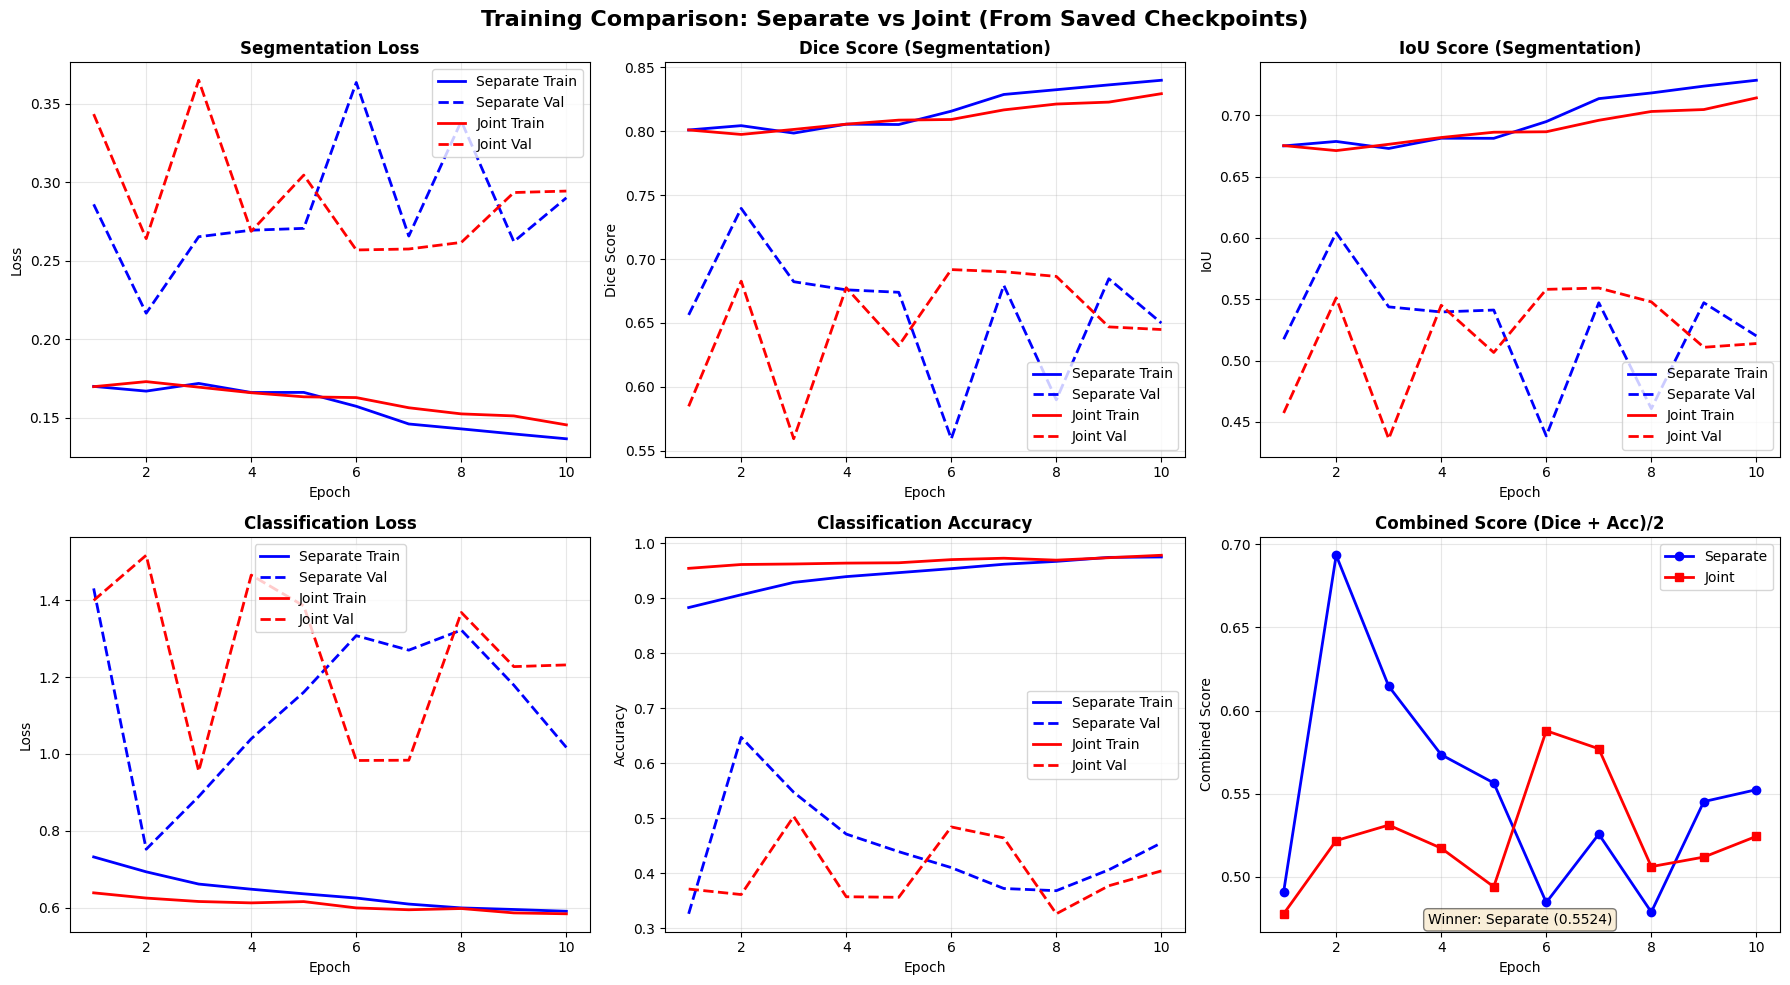

COMPARISON SUMMARY

Checkpoints Used:
  Separate Segmentation: best_segmentation_separate.pth
  Separate Classification: best_classification_separate.pth
  Joint Training: best_joint_training.pth

Final Validation Metrics:
  Metric                         Separate     Joint        Winner    
  ----------------------------------------------------------------
  Segmentation Dice Score        0.6499       0.6448       Separate  
  Segmentation IoU               0.5202       0.5139       Separate  
  Classification Accuracy        0.4550       0.4040       Separate  
  Combined Score (Avg)           0.5524       0.5244       Separate  
FINAL VERDICT:
Separate Training better (Score: 0.5524 vs 0.5244)
   Separate training allows task-specific optimization
   Less interference between segmentation and classification


In [46]:
# After running both OPTION 1 and OPTION 2, compare results from saved checkpoints:
print("\nGenerating Comparison from Saved Checkpoints...")

# Load and compare from .pth files
comparison_results = plot_training_comparison_from_checkpoints(
    seg_checkpoint_path='best_segmentation_separate.pth',
    cls_checkpoint_path='best_classification_separate.pth',
    joint_checkpoint_path='best_joint_training.pth'
)

if comparison_results is not None:
    # Extract final scores
    sep_combined = comparison_results['sep_final_score']
    joint_combined = comparison_results['joint_final_score']
    winner = comparison_results['winner']
    
    print(f"FINAL VERDICT:")
    if joint_combined > sep_combined:
        print(f"Joint Training better (Score: {joint_combined:.4f} vs {sep_combined:.4f})")
        print(f"   Joint training provides better overall performance")
        print(f"   Shared encoder learns better representations for both tasks")
    else:
        print(f"Separate Training better (Score: {sep_combined:.4f} vs {joint_combined:.4f})")
        print(f"   Separate training allows task-specific optimization")
        print(f"   Less interference between segmentation and classification")


## Attention U-Net Joint Training

Based on the comparison showing that **Joint Training (Option 2)** performs better, we implement the same approach for Attention U-Net.

In [47]:
# Train Attention U-Net with Joint Training (Option 2)
# Uses the unified train_model() function with Attention U-Net decoder

# Initialize models
attention_unet_model = AttentionUNet(n_channels=1, n_classes=1).to(device)
classifier_attention = Classifier(in_channels=1024, num_classes=4).to(device)

# Check for checkpoint
if os.path.exists('best_attention_joint_training.pth'):
    print("\nFound attention joint training checkpoint, loading weights")
    checkpoint = torch.load('best_attention_joint_training.pth', map_location=device)
    attention_unet_model.encoder.load_state_dict(checkpoint['encoder'])
    attention_unet_model.bottleneck.load_state_dict(checkpoint['bottleneck'])
    attention_unet_model.decoder.load_state_dict(checkpoint['decoder'])
    classifier_attention.load_state_dict(checkpoint['classifier'])
    if 'history' in checkpoint:
        hist = checkpoint['history']
        dice_str = f"{hist['val_dice'][-1]:.4f}" if 'val_dice' in hist and len(hist['val_dice']) > 0 else 'N/A'
        acc_str = f"{hist['val_acc'][-1]:.4f}" if 'val_acc' in hist and len(hist['val_acc']) > 0 else 'N/A'
        print(f"Loaded attention joint checkpoint (Dice: {dice_str}, Acc: {acc_str})")
    else:
        print("Loaded attention joint checkpoint")

# Train jointly with Attention U-Net (saves to custom path)
attention_history = train_model(
    encoder=attention_unet_model.encoder,
    bottleneck=attention_unet_model.bottleneck,
    decoder_or_attention_decoder=attention_unet_model.decoder,  # AttentionUNetDecoder
    classifier=classifier_attention,
    seg_train_loader=train_seg_loader,
    seg_val_loader=val_seg_loader,
    cls_train_loader=train_cls_loader,
    cls_val_loader=val_cls_loader,
    mode='joint',
    epochs=10,
    lr=0.001,
    device=device,
    w_seg=1.5,
    w_cls=0.5,
    class_weights=class_weights,
    save_path='best_attention_joint_training.pth'  # Custom save path for attention model
)



Found attention joint training checkpoint, loading weights
Loaded attention joint checkpoint (Dice: 0.6592, Acc: 0.5020)
UNIFIED TRAINING - MODE: joint
Training: Encoder + Bottleneck + Decoder + Classifier (Multi-task)
  Loss weights: Segmentation=1.5, Classification=0.5

Epoch [1/10]
  Train - Seg Loss: 0.1880, Dice: 0.7800, IoU: 0.6478
         Cls Loss: 0.6411, Acc: 0.9464
  Val   - Seg Loss: 0.3343, Dice: 0.5972, IoU: 0.4644
         Cls Loss: 1.1687, Acc: 0.3520

Epoch [2/10]
  Train - Seg Loss: 0.1800, Dice: 0.7892, IoU: 0.6597
         Cls Loss: 0.6278, Acc: 0.9518
  Val   - Seg Loss: 0.3108, Dice: 0.6244, IoU: 0.4922
         Cls Loss: 0.7470, Acc: 0.6610

Epoch [4/10]
  Train - Seg Loss: 0.1741, Dice: 0.7961, IoU: 0.6683
         Cls Loss: 0.6158, Acc: 0.9572
  Val   - Seg Loss: 0.3558, Dice: 0.5702, IoU: 0.4417
         Cls Loss: 1.3083, Acc: 0.3690

Epoch [6/10]
  Train - Seg Loss: 0.1605, Dice: 0.8121, IoU: 0.6901
         Cls Loss: 0.6020, Acc: 0.9676
  Val   - Seg Loss: 

## Inference & 6-Panel Visualization

Load trained models and visualize predictions on test data.

In [42]:
def visualize_inference(checkpoint_path, image_path, device='cpu'):
    """
    Run inference on a single image and generate 6-panel visualization.
    
    Args:
        checkpoint_path: Path to model checkpoint ('best_joint_training.pth' or 'best_attention_joint_training.pth')
        image_path: Path to input image (any dimension)
    
    6 Panels:
        1. Input MRI (Original)
        2. Ground Truth Mask (Original) 
        3. Overlay: Ground Truth on Original (Green)
        4. Processed Image (256x256, normalized)
        5. Predicted Mask (256x256)
        6. Overlay: Prediction on Processed (Red)
    """
    
    # Class names for classification
    class_names = ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']
    
    # Load checkpoint
    checkpoint = torch.load(checkpoint_path, map_location=device)
    
    # Determine model type by checking checkpoint structure
    if 'decoder' in checkpoint:
        # Check if decoder contains attention layers
        decoder_keys = checkpoint['decoder'].keys()
        is_attention = any('attention' in key for key in decoder_keys)
    else:
        is_attention = False
    
    if is_attention:
        # Attention U-Net
        model = AttentionUNet(n_channels=1, n_classes=1).to(device)
        
        if 'attention_unet' in checkpoint:
            # Full model saved
            model.load_state_dict(checkpoint['attention_unet'])
        else:
            # Component-wise saved (from train_model with save_path)
            model.encoder.load_state_dict(checkpoint['encoder'])
            model.bottleneck.load_state_dict(checkpoint['bottleneck'])
            model.decoder.load_state_dict(checkpoint['decoder'])
        
        model.eval()
        model_name = "Attention U-Net"
    else:
        # Standard U-Net
        encoder = UNetEncoder(in_channels=1, first_out_channel=64).to(device)
        bottleneck = UNetBottleneck(in_channels=512).to(device)
        decoder = UNetDecoder(in_channels=1024, n_classes=1).to(device)
        
        encoder.load_state_dict(checkpoint['encoder'])
        bottleneck.load_state_dict(checkpoint['bottleneck'])
        decoder.load_state_dict(checkpoint['decoder'])
        
        encoder.eval()
        bottleneck.eval()
        decoder.eval()
        model_name = "Standard U-Net"
    
    # Load classifier if available
    classifier = None
    if 'classifier' in checkpoint:
        classifier = Classifier(in_channels=1024, num_classes=4).to(device)
        classifier.load_state_dict(checkpoint['classifier'])
        classifier.eval()
    
    # Load and process image
    raw_img = Image.open(image_path).convert('L')
    
    # Get ground truth mask if available (same filename pattern)
    mask_path = image_path.replace('images', 'masks').replace('.jpg', '.png')
    raw_mask = None
    if os.path.exists(mask_path):
        raw_mask = Image.open(mask_path).convert('L')
    
    # Apply same preprocessing as training
    pad = squarepad()
    img_padded = pad(raw_img)
    img_resized = transforms.functional.resize(img_padded, [256, 256], 
                                               interpolation=transforms.functional.InterpolationMode.BILINEAR)
    img_tensor = transforms.functional.to_tensor(img_resized)
    img_tensor = transforms.functional.normalize(img_tensor, mean=[TRAIN_MEAN], std=[TRAIN_STD])
    
    # Run inference
    input_tensor = img_tensor.unsqueeze(0).to(device)
    
    with torch.no_grad():
        if is_attention:
            seg_logits = model(input_tensor)
            # Get bottleneck features for classification
            if classifier is not None:
                x1, x2, x3, x4 = model.encoder(input_tensor)
                x5 = model.bottleneck(x4)
                cls_logits = classifier(x5)
        else:
            x1, x2, x3, x4 = encoder(input_tensor)
            x5 = bottleneck(x4)
            seg_logits = decoder(x5, x4, x3, x2, x1)
            # Run classification if available
            if classifier is not None:
                cls_logits = classifier(x5)
        
        pred_mask = (torch.sigmoid(seg_logits) > 0.5).squeeze().cpu().numpy()
        
        # Get classification prediction
        if classifier is not None:
            cls_probs = torch.softmax(cls_logits, dim=1)
            cls_pred = torch.argmax(cls_probs, dim=1).item()
            cls_confidence = cls_probs[0, cls_pred].item()
            predicted_class = class_names[cls_pred]
        else:
            predicted_class = None
            cls_confidence = None
    
    # Denormalize for visualization
    proc_img_display = img_tensor.squeeze().cpu().numpy() * TRAIN_STD + TRAIN_MEAN
    
    # Create 6-panel plot
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f'{model_name} - Inference Result', fontsize=16, fontweight='bold')
    
    # Panel 1: Original Input
    axes[0, 0].imshow(raw_img, cmap='gray')
    axes[0, 0].set_title(f'Input MRI (Original)\n{raw_img.size[0]}×{raw_img.size[1]}')
    axes[0, 0].axis('off')
    
    # Panel 2: Ground Truth Mask
    if raw_mask:
        axes[0, 1].imshow(raw_mask, cmap='gray')
        axes[0, 1].set_title('Ground Truth Mask')
    else:
        axes[0, 1].text(0.5, 0.5, 'No Ground Truth', ha='center', va='center', fontsize=14)
        axes[0, 1].set_title('Ground Truth Mask (N/A)')
    axes[0, 1].axis('off')
    
    # Panel 3: Overlay - Ground Truth (Green)
    axes[0, 2].imshow(raw_img, cmap='gray')
    if raw_mask:
        raw_mask_np = np.array(raw_mask)
        if raw_mask_np.max() > 0:
            axes[0, 2].imshow(np.ma.masked_where(raw_mask_np == 0, raw_mask_np), 
                            cmap='Greens', alpha=0.6)
    axes[0, 2].set_title('Overlay: Ground Truth (Green)')
    axes[0, 2].axis('off')
    
    # Panel 4: Processed Image
    axes[1, 0].imshow(proc_img_display, cmap='gray')
    axes[1, 0].set_title(f'Processed Image\n256×256 (Normalized)')
    axes[1, 0].axis('off')
    
    # Panel 5: Predicted Mask
    axes[1, 1].imshow(pred_mask, cmap='gray')
    axes[1, 1].set_title('Predicted Mask')
    axes[1, 1].axis('off')
    
    # Panel 6: Overlay - Prediction (Red)
    axes[1, 2].imshow(proc_img_display, cmap='gray')
    if pred_mask.max() > 0:
        axes[1, 2].imshow(np.ma.masked_where(pred_mask == 0, pred_mask), 
                        cmap='Reds', alpha=0.6)
    axes[1, 2].set_title('Overlay: Prediction (Red)')
    axes[1, 2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nInference complete using {model_name}")
    print(f"  Image: {os.path.basename(image_path)}")
    print(f"  Tumor detected: {'Yes' if pred_mask.max() > 0 else 'No'}")
    if classifier is not None and predicted_class is not None:
        print(f"  Tumor classification: {predicted_class} (confidence: {cls_confidence:.2%})")
    else:
        print(f"  Classification: Not available (no classifier in checkpoint)")

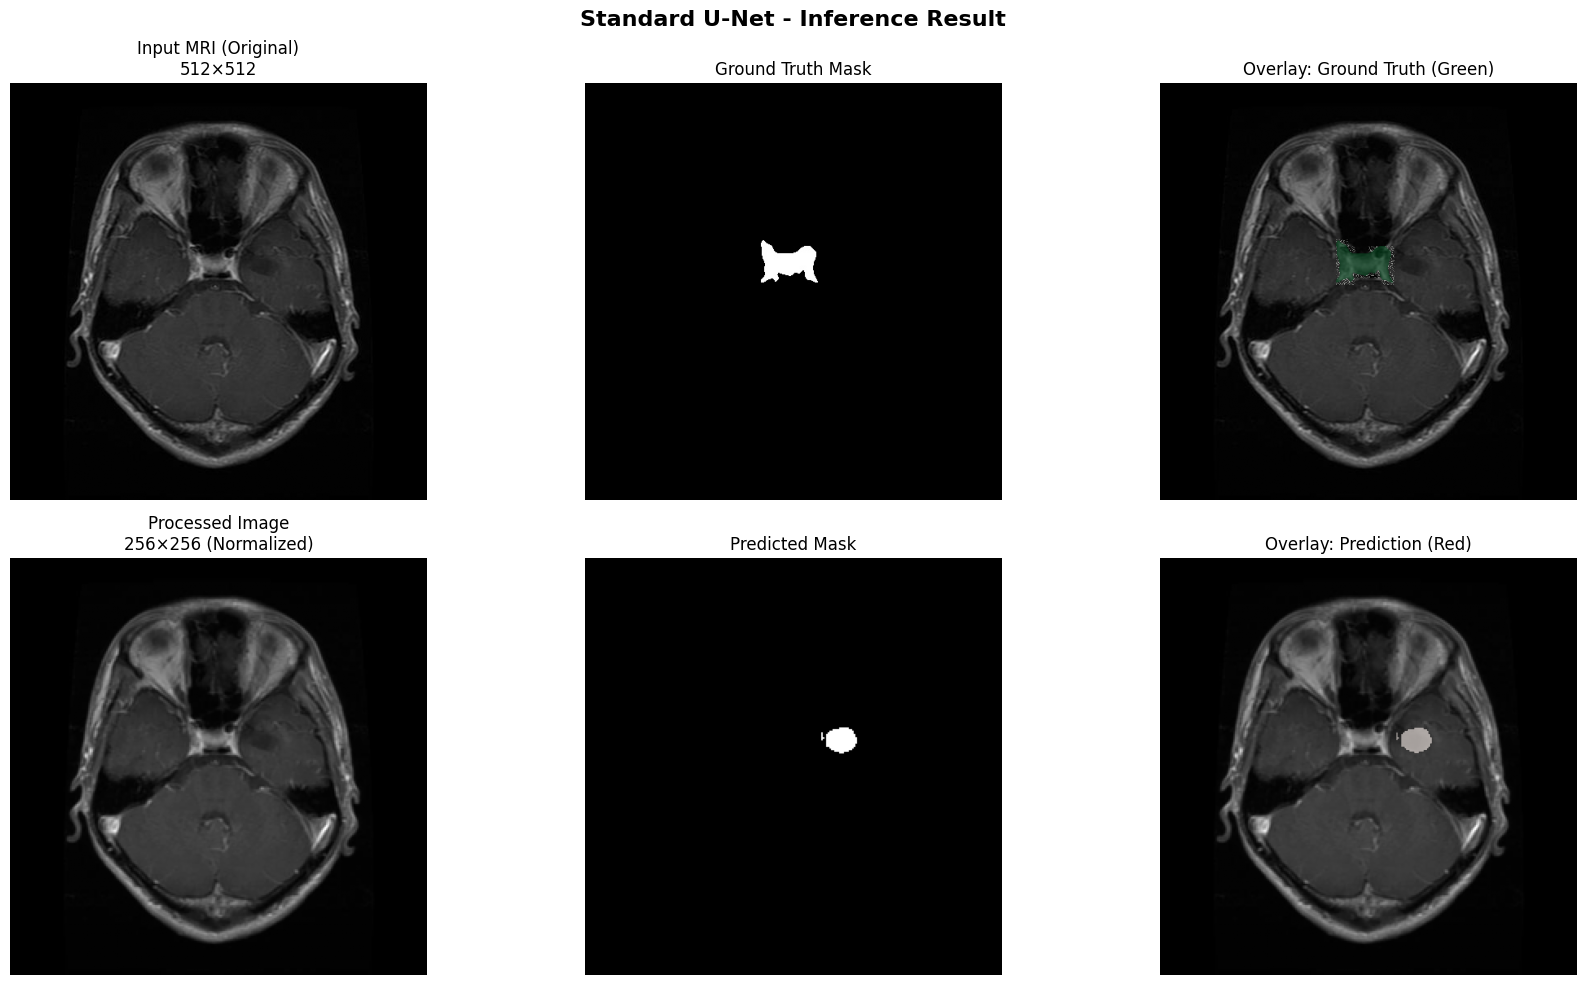


Inference complete using Standard U-Net
  Image: brisc2025_test_00002_gl_ax_t1.jpg
  Tumor detected: Yes
  Tumor classification: Glioma (confidence: 65.52%)


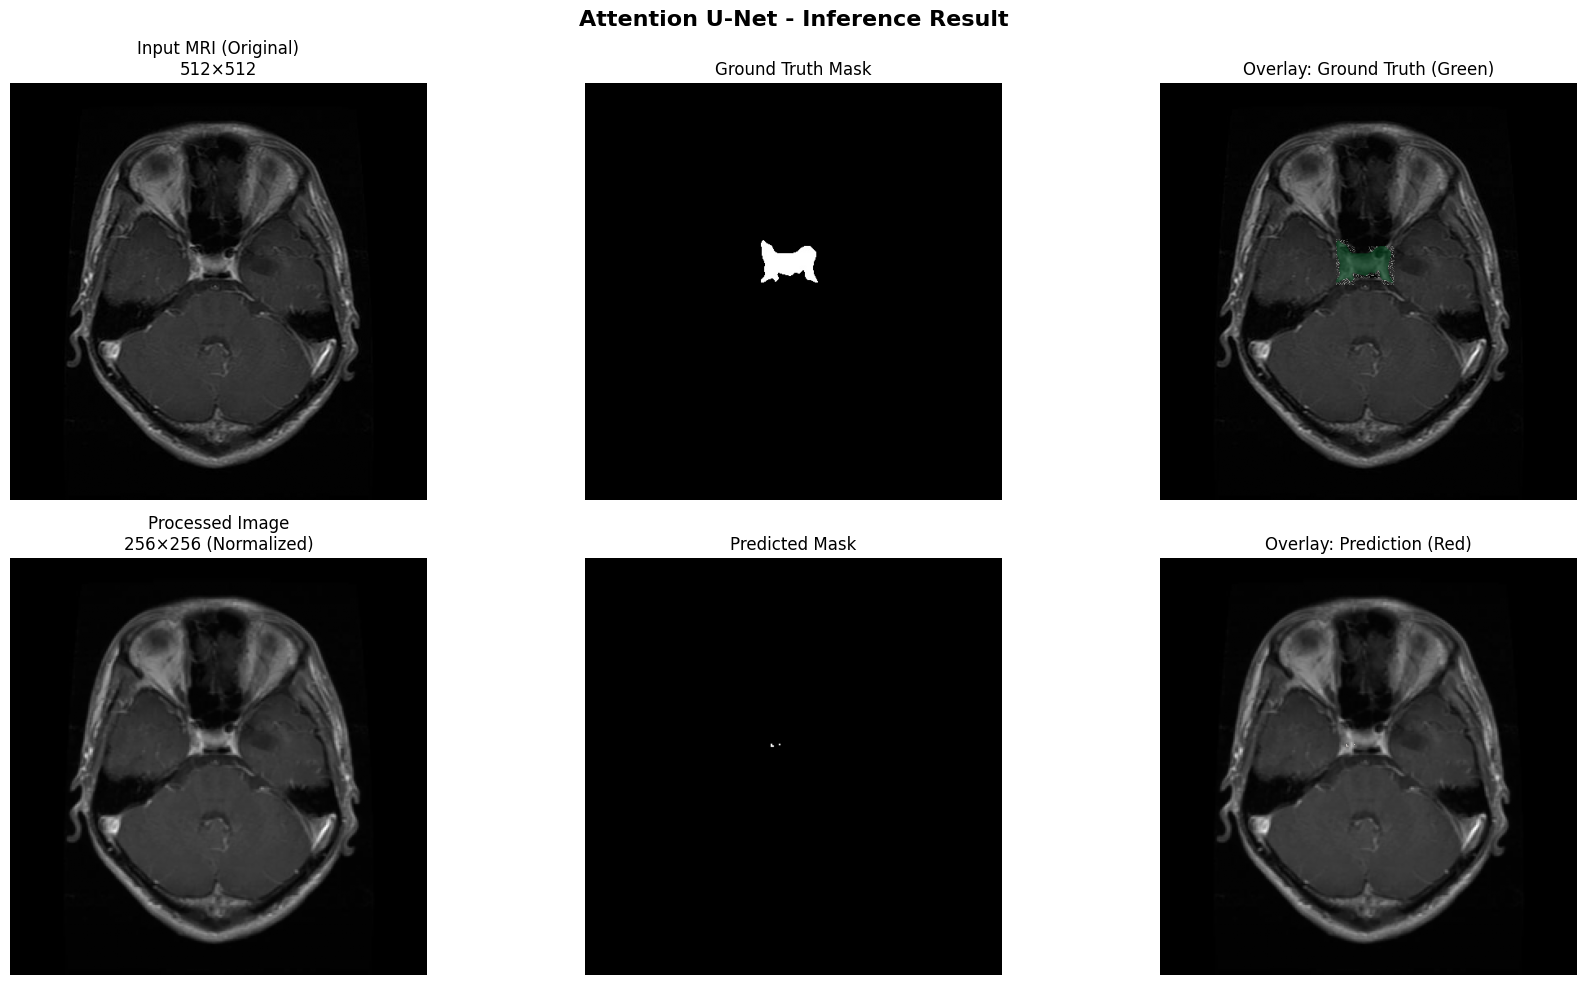


Inference complete using Attention U-Net
  Image: brisc2025_test_00002_gl_ax_t1.jpg
  Tumor detected: Yes
  Tumor classification: Glioma (confidence: 67.45%)


In [43]:
# Example: Run inference on test images

# Using Standard U-Net (Joint Training)
visualize_inference(
    checkpoint_path='best_joint_training.pth',
    image_path='dataset/brisc2025/segmentation_task/test/images/brisc2025_test_00002_gl_ax_t1.jpg',
    device=device
)

# Using Attention U-Net (Joint Training)
visualize_inference(
    checkpoint_path='best_attention_joint_training.pth',
    image_path='dataset/brisc2025/segmentation_task/test/images/brisc2025_test_00002_gl_ax_t1.jpg',
    device=device
)

# print("Inference examples ready (uncomment to run)")